# 08. 운영 효율 분석: 대여소별 수요와 거치대 대비 이용효율

이 노트북은 대여소 단위로 운영 효율을 분석한다.

분석 질문은 다음과 같다.

- 서비스가 수요를 잘 받고 있는가?
- 어디가 과수요인지, 어디가 저활용인지?
- 어떤 대여소는 거치대 대비 이용량이 과도하게 높아 운영 병목이 의심되는가?

분석 지표는 대여소별 이용건수, 거치대 대비 이용효율, 과수요/저활용 대여소 식별이다.

In [1]:
from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
DB_PATH = PROJECT_ROOT / "data" / "seoul_bike.db"
SQL_DIR = PROJECT_ROOT / "sql"
IMAGE_DIR = PROJECT_ROOT / "images" / "station_operation_efficiency"

if not DB_PATH.exists() and Path("/mnt/data/seoul_bike.db").exists():
    PROJECT_ROOT = Path("/mnt/data")
    DB_PATH = PROJECT_ROOT / "seoul_bike.db"
    SQL_DIR = PROJECT_ROOT
    IMAGE_DIR = PROJECT_ROOT / "images" / "station_operation_efficiency"

SQL_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

if not DB_PATH.exists():
    raise FileNotFoundError(f"DB 파일을 찾을 수 없습니다: {DB_PATH}")

conn = sqlite3.connect(DB_PATH)

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type IN ('table', 'view') ORDER BY name", conn)
if "mart_station_efficiency_month" not in set(tables["name"]):
    raise ValueError("mart_station_efficiency_month 테이블이 없습니다. 5단계 mart 생성 노트북을 먼저 실행하세요.")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DB_PATH:", DB_PATH)
print("IMAGE_DIR:", IMAGE_DIR)
print("mart_station_efficiency_month 확인 완료")

PROJECT_ROOT: d:\seoul-bike-aarrr-analysis
DB_PATH: d:\seoul-bike-aarrr-analysis\data\seoul_bike.db
IMAGE_DIR: d:\seoul-bike-aarrr-analysis\images\station_operation_efficiency
mart_station_efficiency_month 확인 완료


In [2]:
available_fonts = {f.name for f in fm.fontManager.ttflist}
for font in ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"]:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        print("Korean font:", font)
        break
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

def read_sql(sql: str) -> pd.DataFrame:
    return pd.read_sql_query(sql, conn)

def save_fig(filename: str) -> Path:
    path = IMAGE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("saved:", path)
    return path

Korean font: Malgun Gothic


## 0. mart 테이블 검증

분석 기간, 행수, 월 수, 대여소 수, 대여소 스냅샷 매칭률, 거치대 결측 여부를 확인한다.

In [3]:
check_sql = r'''
SELECT
    MIN(month_ym) AS min_ym,
    MAX(month_ym) AS max_ym,
    COUNT(*) AS row_count,
    COUNT(DISTINCT month_ym) AS month_count,
    COUNT(DISTINCT station_id) AS station_count,
    SUM(CASE WHEN station_snapshot_matched = 1 THEN 1 ELSE 0 END) AS matched_rows,
    ROUND(100.0 * SUM(CASE WHEN station_snapshot_matched = 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS matched_rate_pct,
    SUM(CASE WHEN rack_cnt IS NULL OR rack_cnt <= 0 THEN 1 ELSE 0 END) AS invalid_rack_rows,
    SUM(CASE WHEN total_ride_cnt IS NULL THEN 1 ELSE 0 END) AS null_total_ride_rows
FROM mart_station_efficiency_month;
'''
check_df = read_sql(check_sql)
check_df

,min_ym,max_ym,row_count,month_count,station_count,matched_rows,matched_rate_pct,invalid_rack_rows,null_total_ride_rows
0,202401,202512,65744,24,2881,65567,99.73,177,0


## 1. 대여소별 이용건수

`total_ride_cnt`를 합산해 분석 기간 동안 이용 수요가 가장 큰 대여소를 확인한다.

In [4]:
station_usage_sql = r'''
WITH base AS (
    SELECT *
    FROM mart_station_efficiency_month
    WHERE station_snapshot_matched = 1
      AND rack_cnt > 0
      AND total_ride_cnt >= 0
),
station_period AS (
    SELECT
        station_id,
        station_name,
        district,
        ROUND(AVG(lat), 6) AS lat,
        ROUND(AVG(lon), 6) AS lon,
        COUNT(DISTINCT month_ym) AS active_month_count,
        SUM(total_ride_cnt) AS total_ride_cnt,
        ROUND(AVG(total_ride_cnt), 2) AS avg_monthly_ride_cnt,
        ROUND(AVG(rack_cnt), 2) AS avg_rack_cnt,
        ROUND(AVG(subscription_share), 4) AS avg_subscription_share
    FROM base
    GROUP BY
        station_id,
        station_name,
        district
)
SELECT
    RANK() OVER (ORDER BY total_ride_cnt DESC) AS ride_rank,
    station_id,
    station_name,
    district,
    lat,
    lon,
    active_month_count,
    CAST(total_ride_cnt AS INTEGER) AS total_ride_cnt,
    avg_monthly_ride_cnt,
    avg_rack_cnt,
    avg_subscription_share
FROM station_period
WHERE lat IS NOT NULL
  AND lon IS NOT NULL
  AND active_month_count = 24
ORDER BY total_ride_cnt DESC
LIMIT 30;
'''
station_usage_df = read_sql(station_usage_sql)
station_usage_df

,ride_rank,station_id,station_name,district,lat,lon,active_month_count,total_ride_cnt,avg_monthly_ride_cnt,avg_rack_cnt,avg_subscription_share
0,1,2715,마곡나루역 2번 출구,강서구,37.566925,126.827438,24,346623,14442.63,25.0,0.8764
1,2,1210,롯데월드타워(잠실역2번출구 쪽),송파구,37.513126,127.100960,24,231422,9642.58,30.0,0.7999
2,3,2728,마곡나루역 3번 출구,강서구,37.565804,126.828079,24,230279,9594.96,55.0,0.8898
3,4,502,뚝섬유원지역 1번출구 앞,광진구,37.531860,127.067192,24,228777,9532.38,33.0,0.6407
4,5,4217,한강공원 망원나들목,마포구,37.555576,126.896889,24,224616,9359.00,20.0,0.5173
5,6,2701,마곡나루역 5번출구 뒤편,강서구,37.565201,126.827316,24,221713,9238.04,26.0,0.9315
6,7,1153,"발산역 1번, 9번 인근 대여소",강서구,37.558949,126.837173,24,191795,7991.46,32.0,0.8548
7,8,230,영등포구청역 1번출구,영등포구,37.524635,126.896217,24,186857,7785.71,13.0,0.8865
8,9,2608,송파구청,송파구,37.515053,127.106270,24,148692,6195.50,10.0,0.8079
9,10,1124,발산역 6번 출구 뒤,강서구,37.558178,126.838455,24,144298,6012.42,6.0,0.8534


saved: d:\seoul-bike-aarrr-analysis\images\station_operation_efficiency\01_top_stations_by_total_rides.png


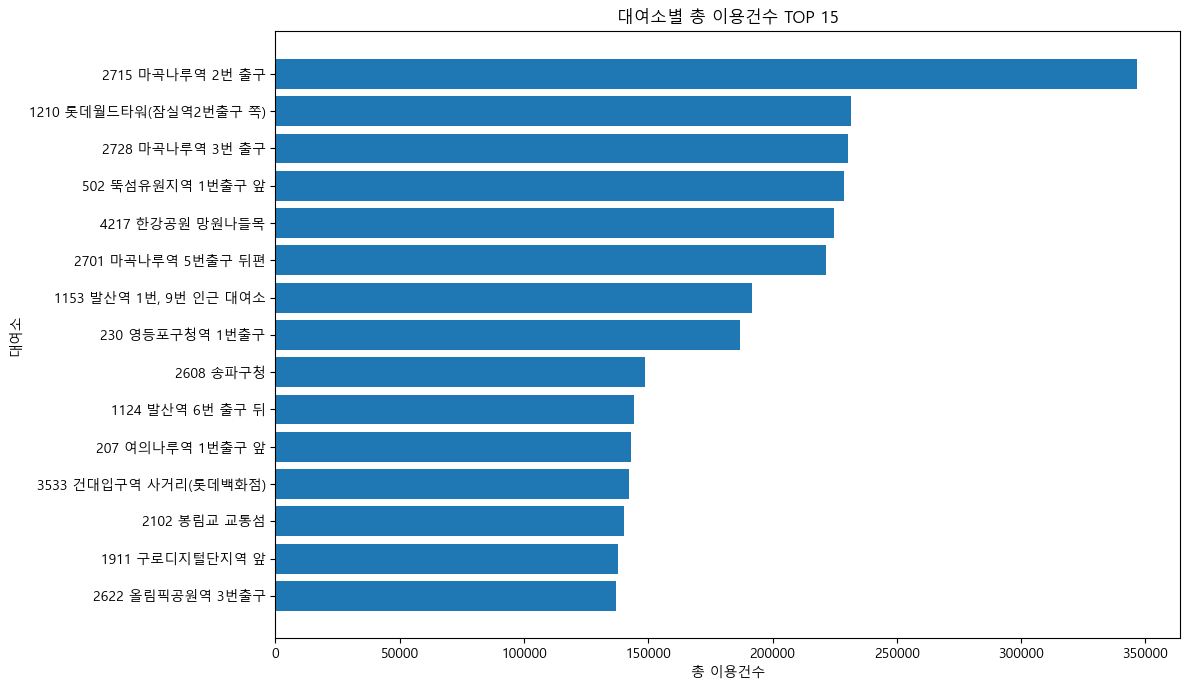

In [5]:
plot_df = station_usage_df.head(15).copy()
plot_df["station_label"] = plot_df["station_id"].astype(str) + " " + plot_df["station_name"].astype(str).str.slice(0, 18)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(plot_df["station_label"][::-1], plot_df["total_ride_cnt"][::-1])
ax.set_title("대여소별 총 이용건수 TOP 15")
ax.set_xlabel("총 이용건수")
ax.set_ylabel("대여소")
save_fig("01_top_stations_by_total_rides.png")
plt.show()

In [6]:
import json
import folium
import branca.colormap as cm

plot_df = station_usage_df.copy()

plot_df = plot_df.dropna(subset=["lat", "lon", "total_ride_cnt"])

MAP_DIR = IMAGE_DIR
MAP_DIR.mkdir(parents=True, exist_ok=True)

# TOP 30 대여소 중심으로 지도 시작점 설정
center_lat = plot_df["lat"].mean()
center_lon = plot_df["lon"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles="CartoDB positron"
)

# 서울특별시 외곽 경계선만 표시
seoul_boundary_path = PROJECT_ROOT / "data" / "skorea_provinces_geo_simple.json"
with open(seoul_boundary_path, encoding="utf-8") as f:
    provinces_geojson = json.load(f)

seoul_boundary_geojson = {
    "type": "FeatureCollection",
    "features": [
        feature
        for feature in provinces_geojson["features"]
        if feature["properties"].get("name_eng") == "Seoul"
    ],
}

folium.GeoJson(
    seoul_boundary_geojson,
    name="서울시 경계",
    style_function=lambda _: {
        "color": "#1f2937",
        "weight": 4,
        "opacity": 0.95,
        "fill": False,
        "fillOpacity": 0,
    },
    tooltip="서울시 경계",
).add_to(m)

# 총 이용건수 기준 색상 스케일
vmin = plot_df["total_ride_cnt"].min()
vmax = plot_df["total_ride_cnt"].max()

colormap = cm.LinearColormap(
    colors=["#fee5d9", "#fcae91", "#fb6a4a", "#de2d26", "#a50f15"],
    vmin=vmin,
    vmax=vmax,
    caption="총 이용건수"
)

colormap.add_to(m)

def get_radius(value):
    # total_ride_cnt 기준 점 크기
    # 너무 커지거나 작아지지 않도록 제한
    min_radius = 5
    max_radius = 16
    
    if vmax == vmin:
        return (min_radius + max_radius) / 2
    
    scaled = min_radius + (value - vmin) / (vmax - vmin) * (max_radius - min_radius)
    return scaled

for _, row in plot_df.iterrows():
    color = colormap(row["total_ride_cnt"])
    radius = get_radius(row["total_ride_cnt"])
    
    popup_html = f"""
    <div style="font-size: 13px;">
        <b>{int(row['ride_rank'])}위 | {row['station_name']}</b><br>
        대여소 ID: {row['station_id']}<br>
        자치구: {row['district']}<br><br>
        총 이용건수: {int(row['total_ride_cnt']):,}건<br>
        월평균 이용건수: {row['avg_monthly_ride_cnt']:,.0f}건<br>
        평균 거치대 수: {row['avg_rack_cnt']:,.1f}개<br>
        평균 정기권 비중: {row['avg_subscription_share']:.1%}
    </div>
    """
    
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.75,
        weight=1,
        popup=folium.Popup(popup_html, max_width=350),
        tooltip=f"{int(row['ride_rank'])}위 | {row['station_name']}"
    ).add_to(m)

# 대여소 전체가 화면에 들어오도록 자동 조정
bounds = [
    [plot_df["lat"].min(), plot_df["lon"].min()],
    [plot_df["lat"].max(), plot_df["lon"].max()]
]
m.fit_bounds(bounds)

map_path = MAP_DIR / "01_top30_station_by_total_rides_map.html"
m.save(map_path)

print(f"saved: {map_path}")
m

saved: d:\seoul-bike-aarrr-analysis\images\station_operation_efficiency\01_top30_station_by_total_rides_map.html


## 2. 거치대 대비 이용효율

이미 mart에 있는 `rides_per_rack`을 사용해 거치대 1개당 월평균 이용량이 높은 대여소를 확인한다.

In [7]:
station_efficiency_sql = r'''
WITH base AS (
    SELECT *
    FROM mart_station_efficiency_month
    WHERE station_snapshot_matched = 1
      AND rack_cnt > 0
      AND total_ride_cnt >= 0
),
station_period AS (
    SELECT
        station_id,
        station_name,
        district,
        ROUND(AVG(lat), 6) AS lat,
        ROUND(AVG(lon), 6) AS lon,
        COUNT(DISTINCT month_ym) AS active_month_count,
        SUM(total_ride_cnt) AS total_ride_cnt,
        ROUND(AVG(total_ride_cnt), 2) AS avg_monthly_ride_cnt,
        ROUND(AVG(rack_cnt), 2) AS avg_rack_cnt,
        ROUND(SUM(total_ride_cnt) / NULLIF(AVG(rack_cnt), 0), 2) AS period_rides_per_rack,
        ROUND(AVG(rides_per_rack), 2) AS avg_monthly_rides_per_rack,
        ROUND(AVG(subscription_share), 4) AS avg_subscription_share
    FROM base
    GROUP BY station_id, station_name, district
)
SELECT
    RANK() OVER (ORDER BY avg_monthly_rides_per_rack DESC) AS efficiency_rank,
    station_id,
    station_name,
    district,
    lat,
    lon,
    active_month_count,
    CAST(total_ride_cnt AS INTEGER) AS total_ride_cnt,
    avg_monthly_ride_cnt,
    avg_rack_cnt,
    period_rides_per_rack,
    avg_monthly_rides_per_rack,
    avg_subscription_share
FROM station_period
WHERE lat IS NOT NULL
  AND lon IS NOT NULL
  AND active_month_count = 24
ORDER BY avg_monthly_rides_per_rack DESC
LIMIT 30;
'''
station_efficiency_df = read_sql(station_efficiency_sql)
station_efficiency_df

,efficiency_rank,station_id,station_name,district,lat,lon,active_month_count,total_ride_cnt,avg_monthly_ride_cnt,avg_rack_cnt,period_rides_per_rack,avg_monthly_rides_per_rack,avg_subscription_share
0,1,1124,발산역 6번 출구 뒤,강서구,37.558178,126.838455,24,144298,6012.42,6.0,24049.67,1002.07,0.8534
1,2,3882,자양2동 주민센터,광진구,37.528793,127.084633,24,48243,2010.13,3.0,16081.00,670.04,0.9155
2,3,2608,송파구청,송파구,37.515053,127.106270,24,148692,6195.50,10.0,14869.20,619.55,0.8079
3,4,4865,한성백제역 1번출구 뒤,송파구,37.516479,127.114983,24,74165,3090.21,5.0,14833.00,618.04,0.8518
4,5,230,영등포구청역 1번출구,영등포구,37.524635,126.896217,24,186857,7785.71,13.0,14373.62,598.90,0.8865
5,6,3533,건대입구역 사거리(롯데백화점),광진구,37.539139,127.070618,24,142118,5921.58,10.0,14211.80,592.16,0.8017
6,7,529,장한평역 8번 출구 앞,성동구,37.561371,127.063660,24,112631,4692.96,8.0,14078.88,586.62,0.8955
7,8,3518,군자역 7번출구뒤,광진구,37.556862,127.079140,24,112185,4674.38,8.0,14023.13,584.30,0.8732
8,9,5301,상계주공1단지 버스정류장 옆(대원빌딩 앞),노원구,37.648060,127.062393,24,56076,2336.50,4.0,14019.00,584.13,0.8604
9,10,2715,마곡나루역 2번 출구,강서구,37.566925,126.827438,24,346623,14442.63,25.0,13864.92,577.71,0.8764


saved: d:\seoul-bike-aarrr-analysis\images\station_operation_efficiency\02_top_stations_by_rides_per_rack.png


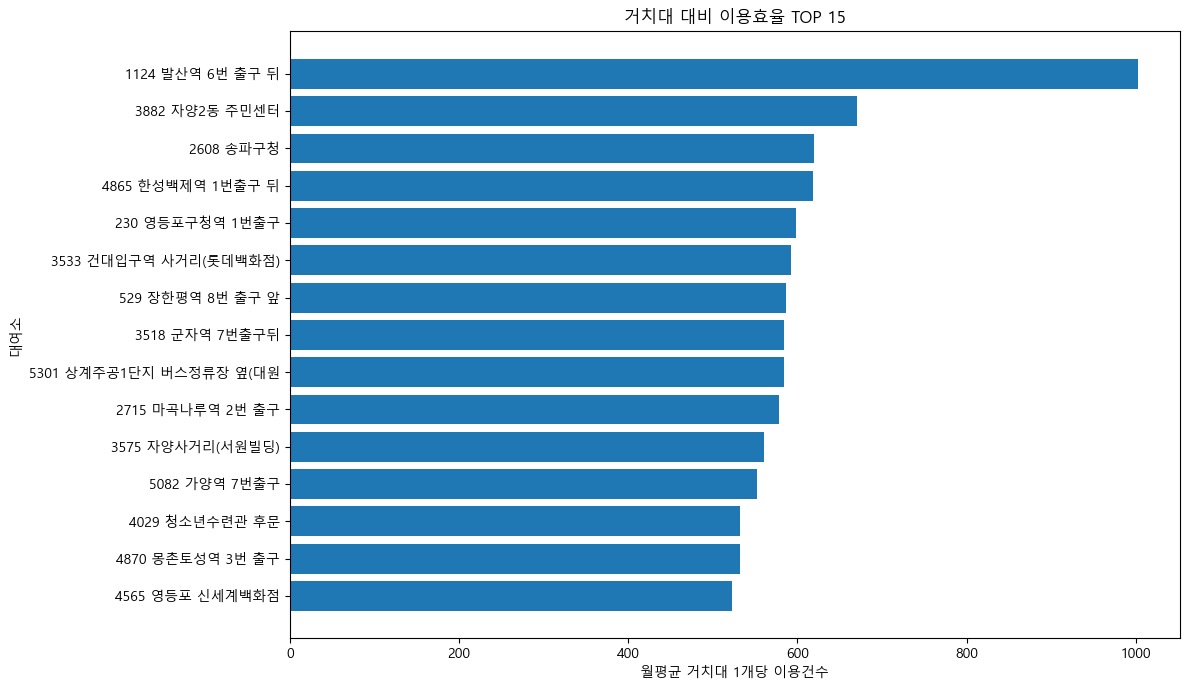

In [8]:
plot_df = station_efficiency_df.head(15).copy()
plot_df["station_label"] = plot_df["station_id"].astype(str) + " " + plot_df["station_name"].astype(str).str.slice(0, 18)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(plot_df["station_label"][::-1], plot_df["avg_monthly_rides_per_rack"][::-1])
ax.set_title("거치대 대비 이용효율 TOP 15")
ax.set_xlabel("월평균 거치대 1개당 이용건수")
ax.set_ylabel("대여소")
save_fig("02_top_stations_by_rides_per_rack.png")
plt.show()

In [9]:
import json
import folium
import branca.colormap as cm

plot_df = station_efficiency_df.copy()

plot_df = plot_df.dropna(subset=["lat", "lon", "avg_monthly_rides_per_rack"])

MAP_DIR = IMAGE_DIR
MAP_DIR.mkdir(parents=True, exist_ok=True)

# TOP 30 대여소 중심으로 지도 시작점 설정
center_lat = plot_df["lat"].mean()
center_lon = plot_df["lon"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles="CartoDB positron"
)

# 서울특별시 외곽 경계선만 표시
seoul_boundary_path = PROJECT_ROOT / "data" / "skorea_provinces_geo_simple.json"
with open(seoul_boundary_path, encoding="utf-8") as f:
    provinces_geojson = json.load(f)

seoul_boundary_geojson = {
    "type": "FeatureCollection",
    "features": [
        feature
        for feature in provinces_geojson["features"]
        if feature["properties"].get("name_eng") == "Seoul"
    ],
}

folium.GeoJson(
    seoul_boundary_geojson,
    name="서울시 경계",
    style_function=lambda _: {
        "color": "#1f2937",
        "weight": 4,
        "opacity": 0.95,
        "fill": False,
        "fillOpacity": 0,
    },
    tooltip="서울시 경계",
).add_to(m)

# 총 이용건수 기준 색상 스케일
vmin = plot_df["avg_monthly_rides_per_rack"].min()
vmax = plot_df["avg_monthly_rides_per_rack"].max()

colormap = cm.LinearColormap(
    colors=["#fee5d9", "#fcae91", "#fb6a4a", "#de2d26", "#a50f15"],
    vmin=vmin,
    vmax=vmax,
    caption="거치대 대비 이용 효율"
)

colormap.add_to(m)

def get_radius(value):
    # avg_monthly_rides_per_rack 기준 점 크기
    # 너무 커지거나 작아지지 않도록 제한
    min_radius = 5
    max_radius = 16
    
    if vmax == vmin:
        return (min_radius + max_radius) / 2
    
    scaled = min_radius + (value - vmin) / (vmax - vmin) * (max_radius - min_radius)
    return scaled

for _, row in plot_df.iterrows():
    color = colormap(row["avg_monthly_rides_per_rack"])
    radius = get_radius(row["avg_monthly_rides_per_rack"])
    
    popup_html = f"""
    <div style="font-size: 13px;">
        <b>{int(row['efficiency_rank'])}위 | {row['station_name']}</b><br>
        대여소 ID: {row['station_id']}<br>
        자치구: {row['district']}<br><br>
        거치대 대비 이용 효율: {int(row['avg_monthly_rides_per_rack']):,}건<br>
        거치대 대비 기간 누적 이용량: {row['period_rides_per_rack']:,.0f}건<br>
        평균 거치대 수: {row['avg_rack_cnt']:,.1f}개<br>
        평균 정기권 비중: {row['avg_subscription_share']:.1%}
    </div>
    """
    
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.75,
        weight=1,
        popup=folium.Popup(popup_html, max_width=350),
        tooltip=f"{int(row['efficiency_rank'])}위 | {row['station_name']}"
    ).add_to(m)

# 대여소 전체가 화면에 들어오도록 자동 조정
bounds = [
    [plot_df["lat"].min(), plot_df["lon"].min()],
    [plot_df["lat"].max(), plot_df["lon"].max()]
]
m.fit_bounds(bounds)

map_path = MAP_DIR / "02_top30_station_by_avg_monthly_rides_per_rack_map.html"
m.save(map_path)

print(f"saved: {map_path}")
m

saved: d:\seoul-bike-aarrr-analysis\images\station_operation_efficiency\02_top30_station_by_avg_monthly_rides_per_rack_map.html


## 3. 과수요/저활용 대여소 식별

총 이용건수와 거치대 대비 이용효율을 각각 4분위로 나누고, 두 지표를 함께 사용해 대여소 유형을 분류한다.

In [10]:
station_type_sql = r'''
WITH base AS (
    SELECT *
    FROM mart_station_efficiency_month
    WHERE station_snapshot_matched = 1
      AND rack_cnt > 0
      AND total_ride_cnt >= 0
),
station_period AS (
    SELECT
        station_id,
        station_name,
        district,
        ROUND(AVG(lat), 6) AS lat,
        ROUND(AVG(lon), 6) AS lon,
        COUNT(DISTINCT month_ym) AS active_month_count,
        SUM(total_ride_cnt) AS total_ride_cnt,
        SUM(sub_ride_cnt) AS total_sub_ride_cnt,
        SUM(non_sub_ride_cnt) AS total_non_sub_ride_cnt,
        ROUND(AVG(total_ride_cnt), 2) AS avg_monthly_ride_cnt,
        ROUND(AVG(rack_cnt), 2) AS avg_rack_cnt,
        ROUND(AVG(rides_per_rack), 2) AS avg_monthly_rides_per_rack,
        ROUND(AVG(subscription_share), 4) AS avg_subscription_share
    FROM base
    GROUP BY station_id, station_name, district
),
ranked AS (
    SELECT
        *,
        NTILE(4) OVER (ORDER BY total_ride_cnt) AS demand_quartile,
        NTILE(4) OVER (ORDER BY avg_monthly_rides_per_rack) AS efficiency_quartile,
        NTILE(4) OVER (ORDER BY avg_rack_cnt) AS rack_quartile
    FROM station_period
    WHERE active_month_count = 24
)
SELECT
    station_id,
    station_name,
    district,
    lat,
    lon,
    active_month_count,
    CAST(total_ride_cnt AS INTEGER) AS total_ride_cnt,
    CAST(total_sub_ride_cnt AS INTEGER) AS total_sub_ride_cnt,
    CAST(total_non_sub_ride_cnt AS INTEGER) AS total_non_sub_ride_cnt,
    avg_monthly_ride_cnt,
    avg_rack_cnt,
    avg_monthly_rides_per_rack,
    avg_subscription_share,
    demand_quartile,
    efficiency_quartile,
    rack_quartile,
    CASE
        WHEN demand_quartile = 4 AND efficiency_quartile = 4 THEN '과수요/운영 병목 의심'
        WHEN demand_quartile <= 2 AND efficiency_quartile = 4 THEN '소규모 고효율'
        WHEN demand_quartile = 1 AND efficiency_quartile = 1 THEN '저활용'
        WHEN demand_quartile = 4 AND efficiency_quartile <= 2 THEN '규모는 크지만 거치대 효율 보통'
        ELSE '일반'
    END AS operation_station_type
FROM ranked
ORDER BY
    CASE
        WHEN demand_quartile = 4 AND efficiency_quartile = 4 THEN 1
        WHEN demand_quartile = 1 AND efficiency_quartile = 1 THEN 2
        WHEN demand_quartile <= 2 AND efficiency_quartile = 4 THEN 3
        WHEN demand_quartile = 4 AND efficiency_quartile <= 2 THEN 4
        ELSE 5
    END,
    avg_monthly_rides_per_rack DESC,
    total_ride_cnt DESC;
'''
station_type_df = read_sql(station_type_sql)
station_type_df

,station_id,station_name,district,lat,lon,active_month_count,total_ride_cnt,total_sub_ride_cnt,total_non_sub_ride_cnt,avg_monthly_ride_cnt,avg_rack_cnt,avg_monthly_rides_per_rack,avg_subscription_share,demand_quartile,efficiency_quartile,rack_quartile,operation_station_type
0,1124,발산역 6번 출구 뒤,강서구,37.558178,126.838455,24,144298,122705,21593,6012.42,6.0,1002.07,0.8534,4,4,1,과수요/운영 병목 의심
1,3882,자양2동 주민센터,광진구,37.528793,127.084633,24,48243,44022,4221,2010.13,3.0,670.04,0.9155,4,4,1,과수요/운영 병목 의심
2,2608,송파구청,송파구,37.515053,127.106270,24,148692,118778,29914,6195.50,10.0,619.55,0.8079,4,4,2,과수요/운영 병목 의심
3,4865,한성백제역 1번출구 뒤,송파구,37.516479,127.114983,24,74165,62594,11571,3090.21,5.0,618.04,0.8518,4,4,1,과수요/운영 병목 의심
4,230,영등포구청역 1번출구,영등포구,37.524635,126.896217,24,186857,164973,21884,7785.71,13.0,598.90,0.8865,4,4,3,과수요/운영 병목 의심
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2556,811,녹사평역1번출구,용산구,37.535080,126.985382,24,12909,8582,4327,537.88,20.0,26.89,0.6758,2,1,4,일반
2557,4316,고속터미널역 3번출구,서초구,37.503658,127.005943,24,15220,12198,3022,634.17,25.0,25.37,0.8117,2,1,4,일반
2558,1998,고척교 교차로,구로구,37.498569,126.871521,24,13920,9615,4305,580.00,23.0,25.22,0.7027,2,1,4,일반
2559,450,효자동 삼거리,종로구,37.583603,126.972549,24,24266,17926,6340,1011.08,51.0,19.83,0.7527,3,1,4,일반


saved: d:\seoul-bike-aarrr-analysis\images\station_operation_efficiency\03_operation_station_type_count.png


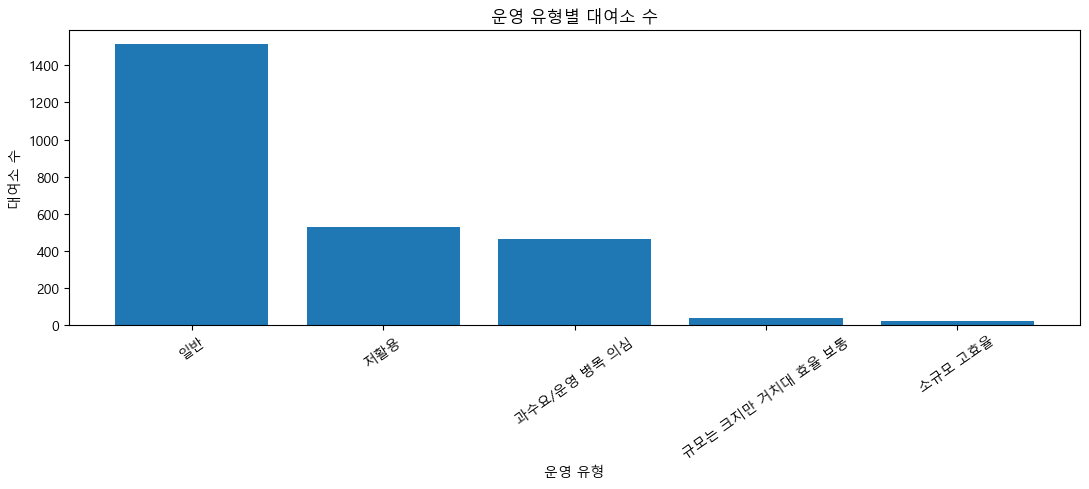

,operation_station_type,station_count
3,일반,1513
4,저활용,526
0,과수요/운영 병목 의심,464
1,규모는 크지만 거치대 효율 보통,39
2,소규모 고효율,19


In [11]:
type_count = station_type_df.groupby("operation_station_type").size().reset_index(name="station_count").sort_values("station_count", ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(type_count["operation_station_type"], type_count["station_count"])
ax.set_title("운영 유형별 대여소 수")
ax.set_xlabel("운영 유형")
ax.set_ylabel("대여소 수")
ax.tick_params(axis="x", rotation=35)
save_fig("03_operation_station_type_count.png")
plt.show()

type_count

In [12]:
over_demand_df = station_type_df[station_type_df["operation_station_type"] == "과수요/운영 병목 의심"].copy()
over_demand_df = over_demand_df.sort_values(["avg_monthly_rides_per_rack", "total_ride_cnt"], ascending=False)
over_demand_df.head(30)

,station_id,station_name,district,lat,lon,active_month_count,total_ride_cnt,total_sub_ride_cnt,total_non_sub_ride_cnt,avg_monthly_ride_cnt,avg_rack_cnt,avg_monthly_rides_per_rack,avg_subscription_share,demand_quartile,efficiency_quartile,rack_quartile,operation_station_type
0,1124,발산역 6번 출구 뒤,강서구,37.558178,126.838455,24,144298,122705,21593,6012.42,6.0,1002.07,0.8534,4,4,1,과수요/운영 병목 의심
1,3882,자양2동 주민센터,광진구,37.528793,127.084633,24,48243,44022,4221,2010.13,3.0,670.04,0.9155,4,4,1,과수요/운영 병목 의심
2,2608,송파구청,송파구,37.515053,127.106270,24,148692,118778,29914,6195.50,10.0,619.55,0.8079,4,4,2,과수요/운영 병목 의심
3,4865,한성백제역 1번출구 뒤,송파구,37.516479,127.114983,24,74165,62594,11571,3090.21,5.0,618.04,0.8518,4,4,1,과수요/운영 병목 의심
4,230,영등포구청역 1번출구,영등포구,37.524635,126.896217,24,186857,164973,21884,7785.71,13.0,598.90,0.8865,4,4,3,과수요/운영 병목 의심
5,3533,건대입구역 사거리(롯데백화점),광진구,37.539139,127.070618,24,142118,112456,29662,5921.58,10.0,592.16,0.8017,4,4,3,과수요/운영 병목 의심
6,529,장한평역 8번 출구 앞,성동구,37.561371,127.063660,24,112631,100493,12138,4692.96,8.0,586.62,0.8955,4,4,1,과수요/운영 병목 의심
7,3518,군자역 7번출구뒤,광진구,37.556862,127.079140,24,112185,97238,14947,4674.38,8.0,584.30,0.8732,4,4,1,과수요/운영 병목 의심
8,5301,상계주공1단지 버스정류장 옆(대원빌딩 앞),노원구,37.648060,127.062393,24,56076,48069,8007,2336.50,4.0,584.13,0.8604,4,4,1,과수요/운영 병목 의심
9,2715,마곡나루역 2번 출구,강서구,37.566925,126.827438,24,346623,302585,44038,14442.63,25.0,577.71,0.8764,4,4,4,과수요/운영 병목 의심


In [13]:
under_use_df = station_type_df[station_type_df["operation_station_type"] == "저활용"].copy()
under_use_df = under_use_df.sort_values(["avg_monthly_rides_per_rack", "total_ride_cnt"], ascending=True)
under_use_df.head(30)

,station_id,station_name,district,lat,lon,active_month_count,total_ride_cnt,total_sub_ride_cnt,total_non_sub_ride_cnt,avg_monthly_ride_cnt,avg_rack_cnt,avg_monthly_rides_per_rack,avg_subscription_share,demand_quartile,efficiency_quartile,rack_quartile,operation_station_type
989,2391,구룡터널 입구(개포1단지아파트),강남구,37.475986,127.059624,24,551,446,105,22.96,7.0,3.28,0.8366,1,1,1,저활용
988,3878,장로회신학대학교 주기철 기념관,광진구,37.549839,127.103027,24,1364,987,377,56.83,15.0,3.79,0.7194,1,1,4,저활용
987,4322,서울추모공원 입구,서초구,37.454300,127.042831,24,1367,1266,101,56.96,15.0,3.80,0.9328,1,1,4,저활용
986,2064,흑석한강푸르지오 106동앞,동작구,37.505356,126.966179,24,1071,891,180,44.63,10.0,4.46,0.8398,1,1,2,저활용
985,2286,탑성마을입구,서초구,37.458549,127.055885,24,761,669,92,31.71,7.0,4.53,0.8526,1,1,1,저활용
984,5327,태릉선수촌 앞,노원구,37.634342,127.104279,24,1200,787,413,50.00,10.0,5.00,0.6426,1,1,3,저활용
983,3971,순흥안씨묘 건너편,금천구,37.458382,126.908073,24,1401,1118,283,58.38,11.0,5.31,0.7892,1,1,3,저활용
982,4523,구립양천어르신요양센터,양천구,37.513512,126.826813,24,2559,2136,423,106.63,20.0,5.33,0.8486,1,1,4,저활용
981,4343,헌인릉 입구,서초구,37.460663,127.081299,24,644,391,253,26.83,5.0,5.37,0.5690,1,1,1,저활용
980,2287,능안마을입구,서초구,37.455620,127.067101,24,1322,1154,168,55.08,10.0,5.51,0.8550,1,1,2,저활용


saved: d:\seoul-bike-aarrr-analysis\images\station_operation_efficiency\04_rack_count_vs_avg_monthly_rides.png


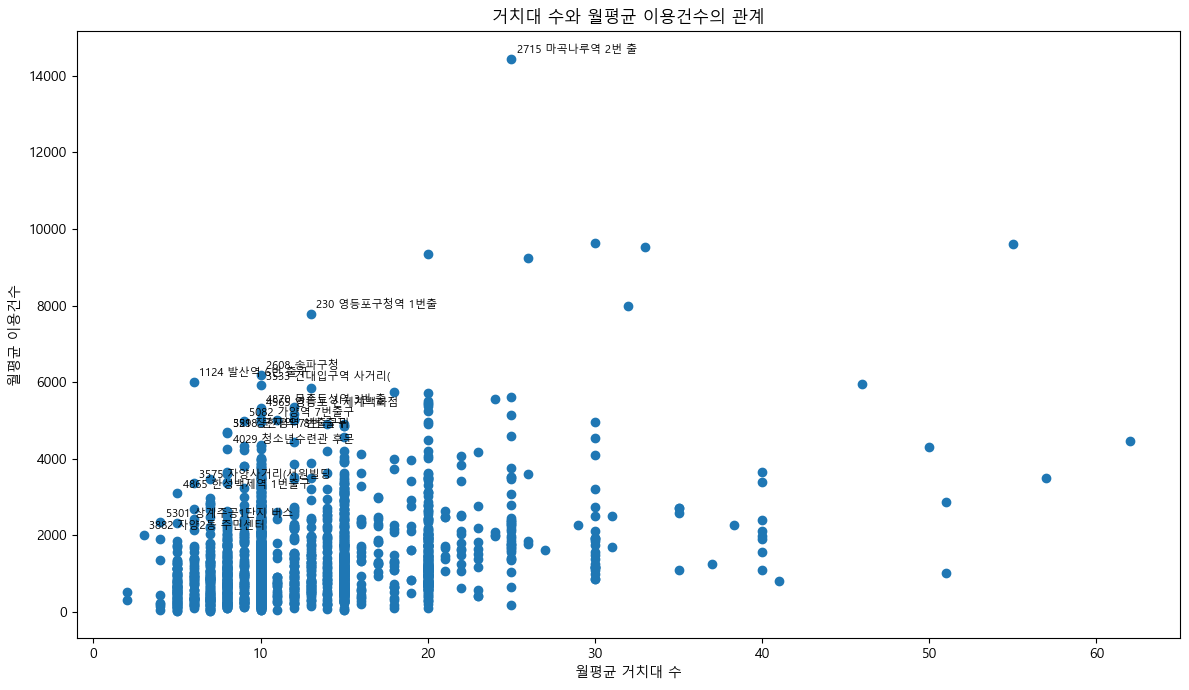

In [14]:
plot_df = station_type_df.copy()

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(plot_df["avg_rack_cnt"], plot_df["avg_monthly_ride_cnt"])
for _, row in plot_df.sort_values("avg_monthly_rides_per_rack", ascending=False).head(15).iterrows():
    label = str(row["station_id"]) + " " + str(row["station_name"])[:10]
    ax.annotate(label, (row["avg_rack_cnt"], row["avg_monthly_ride_cnt"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_title("거치대 수와 월평균 이용건수의 관계")
ax.set_xlabel("월평균 거치대 수")
ax.set_ylabel("월평균 이용건수")
save_fig("04_rack_count_vs_avg_monthly_rides.png")
plt.show()

saved: d:\seoul-bike-aarrr-analysis\images\station_operation_efficiency\05_demand_volume_vs_rack_efficiency.png


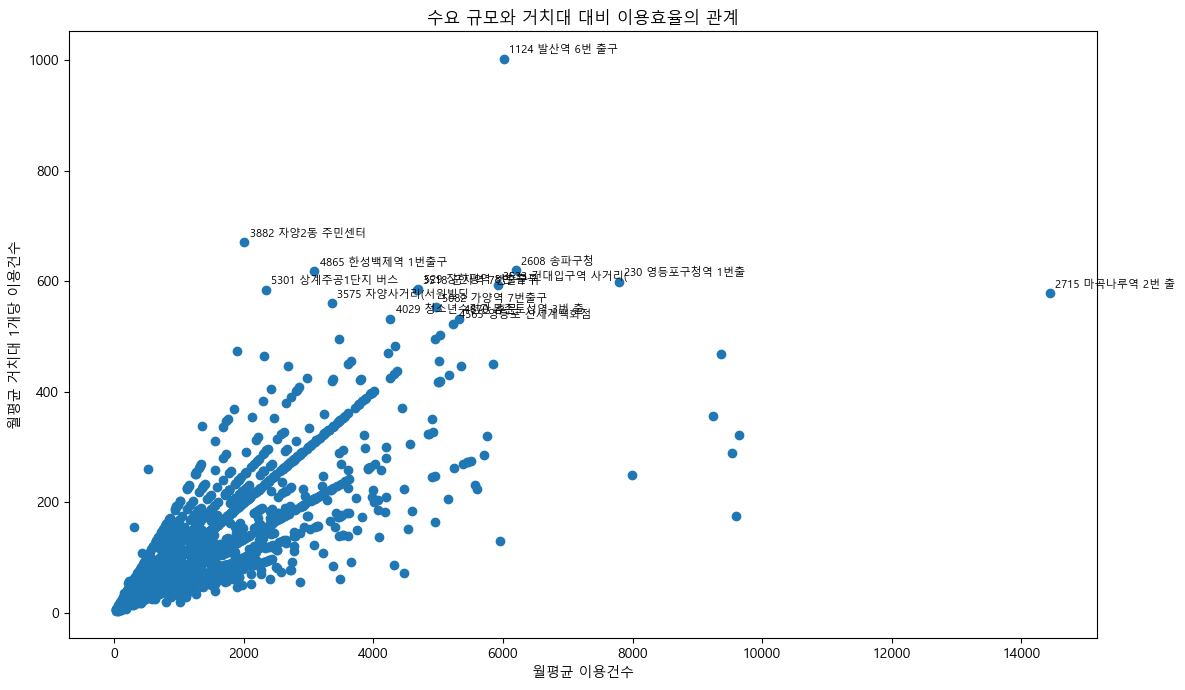

In [15]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(plot_df["avg_monthly_ride_cnt"], plot_df["avg_monthly_rides_per_rack"])
for _, row in plot_df.sort_values("avg_monthly_rides_per_rack", ascending=False).head(15).iterrows():
    label = str(row["station_id"]) + " " + str(row["station_name"])[:10]
    ax.annotate(label, (row["avg_monthly_ride_cnt"], row["avg_monthly_rides_per_rack"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_title("수요 규모와 거치대 대비 이용효율의 관계")
ax.set_xlabel("월평균 이용건수")
ax.set_ylabel("월평균 거치대 1개당 이용건수")
save_fig("05_demand_volume_vs_rack_efficiency.png")
plt.show()

## 4. 월별 반복 과수요 후보

월별로 이용규모와 거치대 대비 효율이 모두 상위권인 대여소를 찾고, 반복 등장 횟수를 계산한다.

In [16]:
monthly_over_sql = r'''
WITH base AS (
    SELECT *
    FROM mart_station_efficiency_month
    WHERE station_snapshot_matched = 1
      AND rack_cnt > 0
      AND total_ride_cnt >= 0
),
ranked_month AS (
    SELECT
        month_ym,
        month_date,
        station_id,
        station_name,
        district,
        lat,
        lon,
        rack_cnt,
        total_ride_cnt,
        rides_per_rack,
        subscription_share,
        NTILE(4) OVER (PARTITION BY month_ym ORDER BY total_ride_cnt) AS demand_quartile_in_month,
        NTILE(4) OVER (PARTITION BY month_ym ORDER BY rides_per_rack) AS efficiency_quartile_in_month
    FROM base
),
over_demand_month AS (
    SELECT *
    FROM ranked_month
    WHERE demand_quartile_in_month = 4
      AND efficiency_quartile_in_month = 4
)
SELECT
    station_id,
    station_name,
    district,
    ROUND(AVG(lat), 6) AS lat,
    ROUND(AVG(lon), 6) AS lon,
    COUNT(*) AS over_demand_month_count,
    CAST(SUM(total_ride_cnt) AS INTEGER) AS total_ride_cnt,
    ROUND(AVG(total_ride_cnt), 2) AS avg_monthly_ride_cnt,
    ROUND(AVG(rack_cnt), 2) AS avg_rack_cnt,
    ROUND(AVG(rides_per_rack), 2) AS avg_monthly_rides_per_rack,
    ROUND(AVG(subscription_share), 4) AS avg_subscription_share
FROM over_demand_month
GROUP BY station_id, station_name, district
HAVING over_demand_month_count >= 18
ORDER BY over_demand_month_count DESC, avg_monthly_rides_per_rack DESC, total_ride_cnt DESC;
'''
monthly_over_df = read_sql(monthly_over_sql)
monthly_over_df

,station_id,station_name,district,lat,lon,over_demand_month_count,total_ride_cnt,avg_monthly_ride_cnt,avg_rack_cnt,avg_monthly_rides_per_rack,avg_subscription_share
0,1124,발산역 6번 출구 뒤,강서구,37.558178,126.838455,24,144298,6012.42,6.0,1002.07,0.8534
1,3882,자양2동 주민센터,광진구,37.528793,127.084633,24,48243,2010.13,3.0,670.04,0.9155
2,2608,송파구청,송파구,37.515053,127.106270,24,148692,6195.50,10.0,619.55,0.8079
3,4865,한성백제역 1번출구 뒤,송파구,37.516479,127.114983,24,74165,3090.21,5.0,618.04,0.8518
4,230,영등포구청역 1번출구,영등포구,37.524635,126.896217,24,186857,7785.71,13.0,598.90,0.8865
...,...,...,...,...,...,...,...,...,...,...,...
415,2032,이수역 11번출구쪽,동작구,37.485508,126.981621,18,29303,1627.94,10.0,162.79,0.8502
416,1449,상봉역 1번출구,중랑구,37.596558,127.085838,18,42845,2380.28,15.0,158.69,0.8723
417,1152,마곡역교차로,강서구,37.558311,126.826523,18,79977,4443.17,30.0,148.11,0.9151
418,1135,강서구의회,강서구,37.546532,126.862549,18,42265,2348.06,16.0,146.75,0.8845


In [17]:
monthly_over_df.head(30)

,station_id,station_name,district,lat,lon,over_demand_month_count,total_ride_cnt,avg_monthly_ride_cnt,avg_rack_cnt,avg_monthly_rides_per_rack,avg_subscription_share
0,1124,발산역 6번 출구 뒤,강서구,37.558178,126.838455,24,144298,6012.42,6.0,1002.07,0.8534
1,3882,자양2동 주민센터,광진구,37.528793,127.084633,24,48243,2010.13,3.0,670.04,0.9155
2,2608,송파구청,송파구,37.515053,127.106270,24,148692,6195.50,10.0,619.55,0.8079
3,4865,한성백제역 1번출구 뒤,송파구,37.516479,127.114983,24,74165,3090.21,5.0,618.04,0.8518
4,230,영등포구청역 1번출구,영등포구,37.524635,126.896217,24,186857,7785.71,13.0,598.90,0.8865
5,3533,건대입구역 사거리(롯데백화점),광진구,37.539139,127.070618,24,142118,5921.58,10.0,592.16,0.8017
6,529,장한평역 8번 출구 앞,성동구,37.561371,127.063660,24,112631,4692.96,8.0,586.62,0.8955
7,3518,군자역 7번출구뒤,광진구,37.556862,127.079140,24,112185,4674.38,8.0,584.30,0.8732
8,5301,상계주공1단지 버스정류장 옆(대원빌딩 앞),노원구,37.648060,127.062393,24,56076,2336.50,4.0,584.13,0.8604
9,2715,마곡나루역 2번 출구,강서구,37.566925,126.827438,24,346623,14442.63,25.0,577.71,0.8764


saved: d:\seoul-bike-aarrr-analysis\images\station_operation_efficiency\06_repeated_over_demand_station_candidates.png


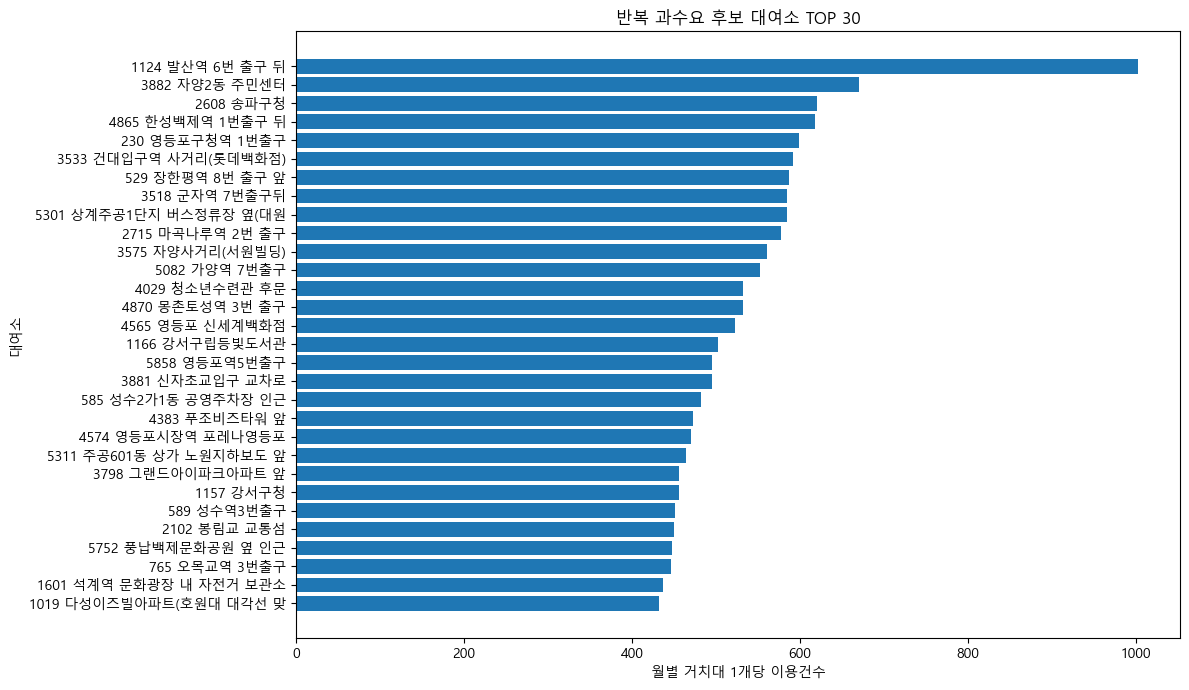

In [18]:
plot_df = monthly_over_df.head(30).copy()
plot_df["station_label"] = plot_df["station_id"].astype(str) + " " + plot_df["station_name"].astype(str).str.slice(0, 18)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(plot_df["station_label"][::-1], plot_df["avg_monthly_rides_per_rack"][::-1])
ax.set_title("반복 과수요 후보 대여소 TOP 30")
ax.set_xlabel("월별 거치대 1개당 이용건수")
ax.set_ylabel("대여소")
save_fig("06_repeated_over_demand_station_candidates.png")
plt.show()

## 5. 월별 반복 저활용 후보

월별로 이용규모와 거치대 대비 효율이 모두 하위권인 대여소를 찾고, 반복 등장 횟수를 계산한다.

In [19]:
monthly_under_sql = r'''
WITH base AS (
    SELECT *
    FROM mart_station_efficiency_month
    WHERE station_snapshot_matched = 1
      AND rack_cnt > 0
      AND total_ride_cnt >= 0
),
ranked_month AS (
    SELECT
        month_ym,
        month_date,
        station_id,
        station_name,
        district,
        lat,
        lon,
        rack_cnt,
        total_ride_cnt,
        rides_per_rack,
        subscription_share,
        NTILE(4) OVER (PARTITION BY month_ym ORDER BY total_ride_cnt) AS demand_quartile_in_month,
        NTILE(4) OVER (PARTITION BY month_ym ORDER BY rides_per_rack) AS efficiency_quartile_in_month
    FROM base
),
under_use_month AS (
    SELECT *
    FROM ranked_month
    WHERE demand_quartile_in_month = 1
      AND efficiency_quartile_in_month = 1
)
SELECT
    station_id,
    station_name,
    district,
    ROUND(AVG(lat), 6) AS lat,
    ROUND(AVG(lon), 6) AS lon,
    COUNT(*) AS under_use_month_count,
    CAST(SUM(total_ride_cnt) AS INTEGER) AS total_ride_cnt,
    ROUND(AVG(total_ride_cnt), 2) AS avg_monthly_ride_cnt,
    ROUND(AVG(rack_cnt), 2) AS avg_rack_cnt,
    ROUND(AVG(rides_per_rack), 2) AS avg_monthly_rides_per_rack,
    ROUND(AVG(subscription_share), 4) AS avg_subscription_share
FROM under_use_month
GROUP BY station_id, station_name, district
HAVING under_use_month_count >= 18
ORDER BY under_use_month_count DESC, avg_monthly_rides_per_rack ASC;
'''
monthly_under_df = read_sql(monthly_under_sql)
monthly_under_df

,station_id,station_name,district,lat,lon,under_use_month_count,total_ride_cnt,avg_monthly_ride_cnt,avg_rack_cnt,avg_monthly_rides_per_rack,avg_subscription_share
0,2391,구룡터널 입구(개포1단지아파트),강남구,37.475986,127.059624,24,551,22.96,7.0,3.28,0.8366
1,3878,장로회신학대학교 주기철 기념관,광진구,37.549839,127.103027,24,1364,56.83,15.0,3.79,0.7194
2,4322,서울추모공원 입구,서초구,37.454300,127.042831,24,1367,56.96,15.0,3.80,0.9328
3,2064,흑석한강푸르지오 106동앞,동작구,37.505356,126.966179,24,1071,44.63,10.0,4.46,0.8398
4,2286,탑성마을입구,서초구,37.458549,127.055885,24,761,31.71,7.0,4.53,0.8526
...,...,...,...,...,...,...,...,...,...,...,...
450,479,동대입구역 3번 출구,중구,37.559376,127.006027,18,5733,318.50,8.0,39.81,0.8322
451,4086,도봉로 534,도봉구,37.652954,127.037544,18,7236,402.00,10.0,40.20,0.8782
452,4881,거여동사거리 송파둘레길 입구,송파구,37.495358,127.139473,18,3668,203.78,5.0,40.76,0.8434
453,3622,은마아파트입구 사거리(1),강남구,37.499866,127.060501,18,5140,285.56,7.0,40.79,0.8351


In [20]:
monthly_under_df.head(30)

,station_id,station_name,district,lat,lon,under_use_month_count,total_ride_cnt,avg_monthly_ride_cnt,avg_rack_cnt,avg_monthly_rides_per_rack,avg_subscription_share
0,2391,구룡터널 입구(개포1단지아파트),강남구,37.475986,127.059624,24,551,22.96,7.0,3.28,0.8366
1,3878,장로회신학대학교 주기철 기념관,광진구,37.549839,127.103027,24,1364,56.83,15.0,3.79,0.7194
2,4322,서울추모공원 입구,서초구,37.454300,127.042831,24,1367,56.96,15.0,3.80,0.9328
3,2064,흑석한강푸르지오 106동앞,동작구,37.505356,126.966179,24,1071,44.63,10.0,4.46,0.8398
4,2286,탑성마을입구,서초구,37.458549,127.055885,24,761,31.71,7.0,4.53,0.8526
5,5327,태릉선수촌 앞,노원구,37.634342,127.104279,24,1200,50.00,10.0,5.00,0.6426
6,3971,순흥안씨묘 건너편,금천구,37.458382,126.908073,24,1401,58.38,11.0,5.31,0.7892
7,4523,구립양천어르신요양센터,양천구,37.513512,126.826813,24,2559,106.63,20.0,5.33,0.8486
8,4343,헌인릉 입구,서초구,37.460663,127.081299,24,644,26.83,5.0,5.37,0.5690
9,2287,능안마을입구,서초구,37.455620,127.067101,24,1322,55.08,10.0,5.51,0.8550


saved: d:\seoul-bike-aarrr-analysis\images\station_operation_efficiency\07_repeated_under_used_station_candidates.png


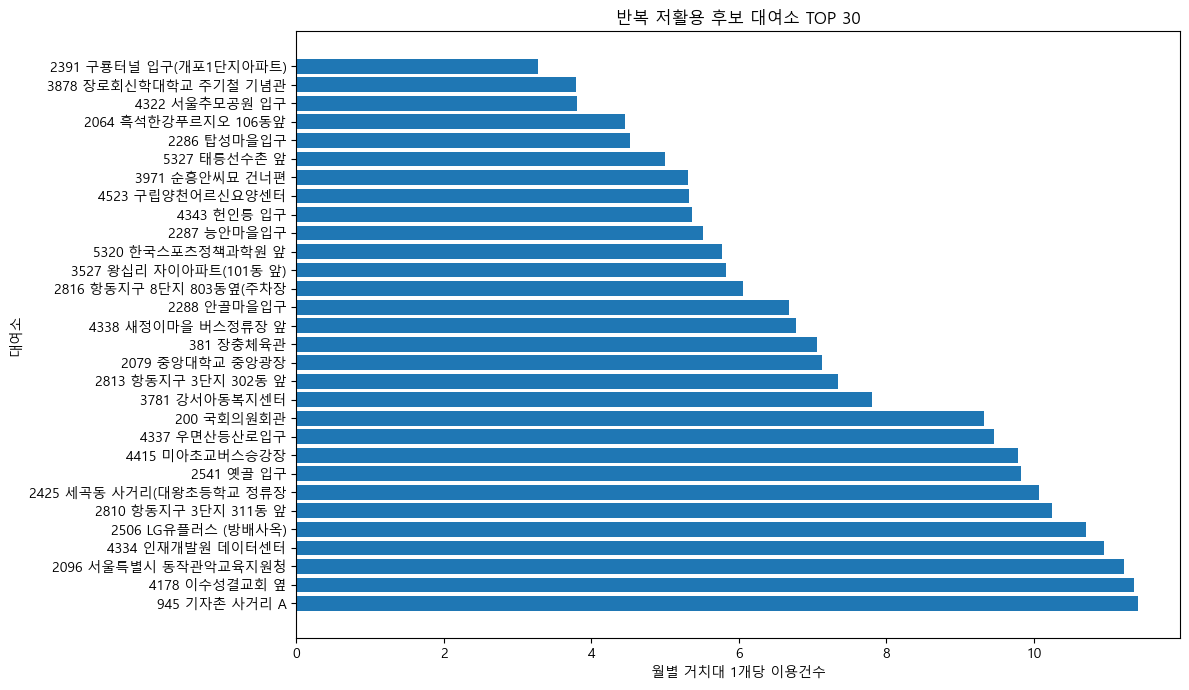

In [21]:
plot_df = monthly_under_df.head(30).copy()
plot_df["station_label"] = plot_df["station_id"].astype(str) + " " + plot_df["station_name"].astype(str).str.slice(0, 18)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(plot_df["station_label"][::-1], plot_df["avg_monthly_rides_per_rack"][::-1])
ax.set_title("반복 저활용 후보 대여소 TOP 30")
ax.set_xlabel("월별 거치대 1개당 이용건수")
ax.set_ylabel("대여소")
save_fig("07_repeated_under_used_station_candidates.png")
plt.show()

## 6. 10분위 기준 과수요/저활용 대여소 식별 및 월별 반복 과수요/저활용 후보

- 총 이용건수와 거치대 대비 이용효율을 각각 10분위로 나누고, 두 지표를 함께 사용해 대여소 유형을 분류한다.
- 월별로 이용규모와 거치대 대비 효율이 모두 상위권인 대여소를 찾고, 반복 등장 횟수를 계산한다.
- 월별로 이용규모와 거치대 대비 효율이 모두 하위권인 대여소를 찾고, 반복 등장 횟수를 계산한다.

In [22]:
station_type_10tile_sql = r"""
WITH base AS (
    SELECT *
    FROM mart_station_efficiency_month
    WHERE station_snapshot_matched = 1
      AND rack_cnt > 0
      AND total_ride_cnt >= 0
),
station_period AS (
    SELECT
        station_id,
        station_name,
        district,
        ROUND(AVG(lat), 6) AS lat,
        ROUND(AVG(lon), 6) AS lon,
        COUNT(DISTINCT month_ym) AS active_month_count,
        SUM(total_ride_cnt) AS total_ride_cnt,
        SUM(sub_ride_cnt) AS total_sub_ride_cnt,
        SUM(non_sub_ride_cnt) AS total_non_sub_ride_cnt,
        ROUND(AVG(total_ride_cnt), 2) AS avg_monthly_ride_cnt,
        ROUND(AVG(rack_cnt), 2) AS avg_rack_cnt,
        ROUND(AVG(rides_per_rack), 2) AS avg_monthly_rides_per_rack,
        ROUND(AVG(subscription_share), 4) AS avg_subscription_share
    FROM base
    GROUP BY station_id, station_name, district
),
ranked AS (
    SELECT
        *,
        NTILE(10) OVER (ORDER BY total_ride_cnt) AS demand_decile,
        NTILE(10) OVER (ORDER BY avg_monthly_rides_per_rack) AS efficiency_decile,
        NTILE(10) OVER (ORDER BY avg_rack_cnt) AS rack_decile
    FROM station_period
    WHERE active_month_count = 24
)
SELECT
    station_id,
    station_name,
    district,
    lat,
    lon,
    active_month_count,
    CAST(total_ride_cnt AS INTEGER) AS total_ride_cnt,
    CAST(total_sub_ride_cnt AS INTEGER) AS total_sub_ride_cnt,
    CAST(total_non_sub_ride_cnt AS INTEGER) AS total_non_sub_ride_cnt,
    avg_monthly_ride_cnt,
    avg_rack_cnt,
    avg_monthly_rides_per_rack,
    avg_subscription_share,
    demand_decile,
    efficiency_decile,
    rack_decile,
    CASE
        WHEN demand_decile = 10 AND efficiency_decile = 10 THEN '핵심 과수요/운영 병목 후보'
        WHEN demand_decile = 1 AND efficiency_decile = 1 THEN '핵심 저활용 후보'
        WHEN demand_decile <= 5 AND efficiency_decile = 10 THEN '소규모 고효율 후보'
        WHEN demand_decile = 10 AND efficiency_decile <= 5 THEN '대형 수요 안정 처리 후보'
        ELSE '일반'
    END AS operation_station_type
FROM ranked
ORDER BY
    CASE
        WHEN demand_decile = 10 AND efficiency_decile = 10 THEN 1
        WHEN demand_decile = 1 AND efficiency_decile = 1 THEN 2
        WHEN demand_decile <= 5 AND efficiency_decile = 10 THEN 3
        WHEN demand_decile = 10 AND efficiency_decile <= 5 THEN 4
        ELSE 5
    END,
    avg_monthly_rides_per_rack DESC,
    total_ride_cnt DESC;
"""
station_type_10tile_df = read_sql(station_type_10tile_sql)
station_type_10tile_df

,station_id,station_name,district,lat,lon,active_month_count,total_ride_cnt,total_sub_ride_cnt,total_non_sub_ride_cnt,avg_monthly_ride_cnt,avg_rack_cnt,avg_monthly_rides_per_rack,avg_subscription_share,demand_decile,efficiency_decile,rack_decile,operation_station_type
0,1124,발산역 6번 출구 뒤,강서구,37.558178,126.838455,24,144298,122705,21593,6012.42,6.0,1002.07,0.8534,10,10,1,핵심 과수요/운영 병목 후보
1,2608,송파구청,송파구,37.515053,127.106270,24,148692,118778,29914,6195.50,10.0,619.55,0.8079,10,10,5,핵심 과수요/운영 병목 후보
2,4865,한성백제역 1번출구 뒤,송파구,37.516479,127.114983,24,74165,62594,11571,3090.21,5.0,618.04,0.8518,10,10,1,핵심 과수요/운영 병목 후보
3,230,영등포구청역 1번출구,영등포구,37.524635,126.896217,24,186857,164973,21884,7785.71,13.0,598.90,0.8865,10,10,7,핵심 과수요/운영 병목 후보
4,3533,건대입구역 사거리(롯데백화점),광진구,37.539139,127.070618,24,142118,112456,29662,5921.58,10.0,592.16,0.8017,10,10,6,핵심 과수요/운영 병목 후보
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2556,3902,항동지구5단지 501동 앞,구로구,37.478199,126.824875,24,6639,5354,1285,276.63,16.0,17.29,0.8126,2,1,9,일반
2557,4892,성내유수지 체육공원,송파구,37.525970,127.118210,24,7357,5865,1492,306.54,18.0,17.03,0.8048,2,1,9,일반
2558,4827,신내SK V1센터 앞,중랑구,37.612724,127.113060,24,7517,6481,1036,313.21,20.0,15.66,0.8643,2,1,10,일반
2559,2094,숭실대학교(중문),동작구,37.495506,126.956375,24,6981,4983,1998,290.88,20.0,14.54,0.7340,2,1,10,일반


saved: d:\seoul-bike-aarrr-analysis\images\station_operation_efficiency\08_operation_station_type_10tile_count.png


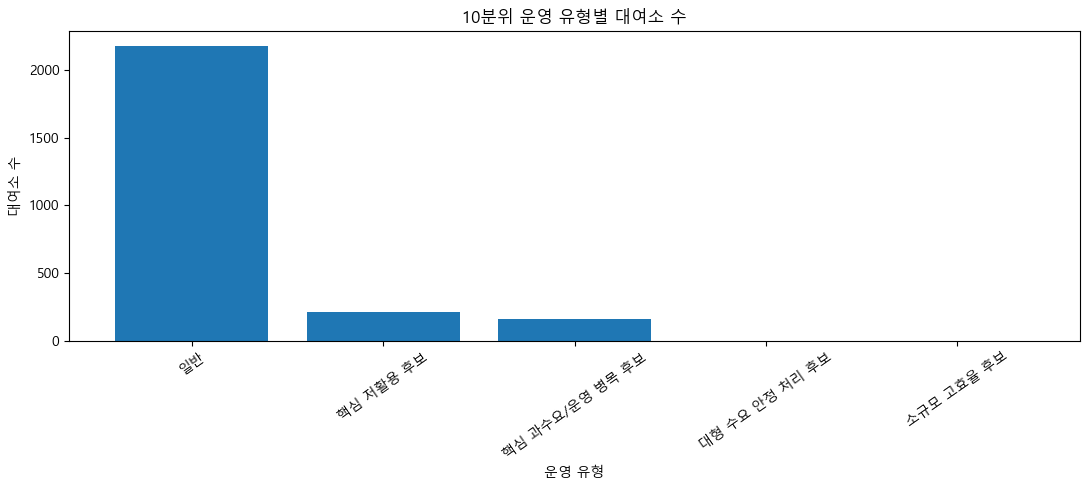

,operation_station_type,station_count
2,일반,2173
4,핵심 저활용 후보,218
3,핵심 과수요/운영 병목 후보,164
0,대형 수요 안정 처리 후보,5
1,소규모 고효율 후보,1


In [23]:
type_10tile_count = station_type_10tile_df.groupby("operation_station_type").size().reset_index(name="station_count").sort_values("station_count", ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(type_10tile_count["operation_station_type"], type_10tile_count["station_count"])
ax.set_title("10분위 운영 유형별 대여소 수")
ax.set_xlabel("운영 유형")
ax.set_ylabel("대여소 수")
ax.tick_params(axis="x", rotation=35)
save_fig("08_operation_station_type_10tile_count.png")
plt.show()

type_10tile_count

In [24]:
over_demand_10tile_df = station_type_10tile_df[station_type_10tile_df["operation_station_type"] == "핵심 과수요/운영 병목 후보"].copy()
over_demand_10tile_df = over_demand_10tile_df.sort_values(["avg_monthly_rides_per_rack", "total_ride_cnt"], ascending=False)
over_demand_10tile_df.head(30)

,station_id,station_name,district,lat,lon,active_month_count,total_ride_cnt,total_sub_ride_cnt,total_non_sub_ride_cnt,avg_monthly_ride_cnt,avg_rack_cnt,avg_monthly_rides_per_rack,avg_subscription_share,demand_decile,efficiency_decile,rack_decile,operation_station_type
0,1124,발산역 6번 출구 뒤,강서구,37.558178,126.838455,24,144298,122705,21593,6012.42,6.0,1002.07,0.8534,10,10,1,핵심 과수요/운영 병목 후보
1,2608,송파구청,송파구,37.515053,127.106270,24,148692,118778,29914,6195.50,10.0,619.55,0.8079,10,10,5,핵심 과수요/운영 병목 후보
2,4865,한성백제역 1번출구 뒤,송파구,37.516479,127.114983,24,74165,62594,11571,3090.21,5.0,618.04,0.8518,10,10,1,핵심 과수요/운영 병목 후보
3,230,영등포구청역 1번출구,영등포구,37.524635,126.896217,24,186857,164973,21884,7785.71,13.0,598.90,0.8865,10,10,7,핵심 과수요/운영 병목 후보
4,3533,건대입구역 사거리(롯데백화점),광진구,37.539139,127.070618,24,142118,112456,29662,5921.58,10.0,592.16,0.8017,10,10,6,핵심 과수요/운영 병목 후보
5,529,장한평역 8번 출구 앞,성동구,37.561371,127.063660,24,112631,100493,12138,4692.96,8.0,586.62,0.8955,10,10,2,핵심 과수요/운영 병목 후보
6,3518,군자역 7번출구뒤,광진구,37.556862,127.079140,24,112185,97238,14947,4674.38,8.0,584.30,0.8732,10,10,2,핵심 과수요/운영 병목 후보
7,2715,마곡나루역 2번 출구,강서구,37.566925,126.827438,24,346623,302585,44038,14442.63,25.0,577.71,0.8764,10,10,10,핵심 과수요/운영 병목 후보
8,3575,자양사거리(서원빌딩),광진구,37.536575,127.082581,24,80650,69462,11188,3360.42,6.0,560.07,0.8672,10,10,1,핵심 과수요/운영 병목 후보
9,5082,가양역 7번출구,강서구,37.560196,126.854912,24,119326,105375,13951,4971.92,9.0,552.44,0.8873,10,10,2,핵심 과수요/운영 병목 후보


In [25]:
under_use_10tile_df = station_type_10tile_df[station_type_10tile_df["operation_station_type"] == "핵심 저활용 후보"].copy()
under_use_10tile_df = under_use_10tile_df.sort_values(["avg_monthly_rides_per_rack", "total_ride_cnt"], ascending=True)
under_use_10tile_df.head(30)

,station_id,station_name,district,lat,lon,active_month_count,total_ride_cnt,total_sub_ride_cnt,total_non_sub_ride_cnt,avg_monthly_ride_cnt,avg_rack_cnt,avg_monthly_rides_per_rack,avg_subscription_share,demand_decile,efficiency_decile,rack_decile,operation_station_type
381,2391,구룡터널 입구(개포1단지아파트),강남구,37.475986,127.059624,24,551,446,105,22.96,7.0,3.28,0.8366,1,1,1,핵심 저활용 후보
380,3878,장로회신학대학교 주기철 기념관,광진구,37.549839,127.103027,24,1364,987,377,56.83,15.0,3.79,0.7194,1,1,9,핵심 저활용 후보
379,4322,서울추모공원 입구,서초구,37.454300,127.042831,24,1367,1266,101,56.96,15.0,3.80,0.9328,1,1,9,핵심 저활용 후보
378,2064,흑석한강푸르지오 106동앞,동작구,37.505356,126.966179,24,1071,891,180,44.63,10.0,4.46,0.8398,1,1,5,핵심 저활용 후보
377,2286,탑성마을입구,서초구,37.458549,127.055885,24,761,669,92,31.71,7.0,4.53,0.8526,1,1,1,핵심 저활용 후보
376,5327,태릉선수촌 앞,노원구,37.634342,127.104279,24,1200,787,413,50.00,10.0,5.00,0.6426,1,1,7,핵심 저활용 후보
375,3971,순흥안씨묘 건너편,금천구,37.458382,126.908073,24,1401,1118,283,58.38,11.0,5.31,0.7892,1,1,7,핵심 저활용 후보
374,4523,구립양천어르신요양센터,양천구,37.513512,126.826813,24,2559,2136,423,106.63,20.0,5.33,0.8486,1,1,10,핵심 저활용 후보
373,4343,헌인릉 입구,서초구,37.460663,127.081299,24,644,391,253,26.83,5.0,5.37,0.5690,1,1,1,핵심 저활용 후보
372,2287,능안마을입구,서초구,37.455620,127.067101,24,1322,1154,168,55.08,10.0,5.51,0.8550,1,1,5,핵심 저활용 후보


In [26]:
monthly_over_10tile_sql = r'''
WITH base AS (
    SELECT *
    FROM mart_station_efficiency_month
    WHERE station_snapshot_matched = 1
      AND rack_cnt > 0
      AND total_ride_cnt >= 0
),
ranked_month AS (
    SELECT
        month_ym,
        month_date,
        station_id,
        station_name,
        district,
        lat,
        lon,
        rack_cnt,
        total_ride_cnt,
        rides_per_rack,
        subscription_share,
        NTILE(10) OVER (PARTITION BY month_ym ORDER BY total_ride_cnt) AS demand_decile_in_month,
        NTILE(10) OVER (PARTITION BY month_ym ORDER BY rides_per_rack) AS efficiency_decile_in_month
    FROM base
),
over_demand_month AS (
    SELECT *
    FROM ranked_month
    WHERE demand_decile_in_month = 10
      AND efficiency_decile_in_month = 10
)
SELECT
    station_id,
    station_name,
    district,
    ROUND(AVG(lat), 6) AS lat,
    ROUND(AVG(lon), 6) AS lon,
    COUNT(*) AS over_demand_month_count,
    CAST(SUM(total_ride_cnt) AS INTEGER) AS total_ride_cnt,
    ROUND(AVG(total_ride_cnt), 2) AS avg_monthly_ride_cnt,
    ROUND(AVG(rack_cnt), 2) AS avg_rack_cnt,
    ROUND(AVG(rides_per_rack), 2) AS avg_monthly_rides_per_rack,
    ROUND(AVG(subscription_share), 4) AS avg_subscription_share
FROM over_demand_month
GROUP BY station_id, station_name, district
HAVING over_demand_month_count = 24
ORDER BY over_demand_month_count DESC, avg_monthly_rides_per_rack DESC, total_ride_cnt DESC;
'''
monthly_over_10tile_df = read_sql(monthly_over_10tile_sql)
monthly_over_10tile_df

,station_id,station_name,district,lat,lon,over_demand_month_count,total_ride_cnt,avg_monthly_ride_cnt,avg_rack_cnt,avg_monthly_rides_per_rack,avg_subscription_share
0,1124,발산역 6번 출구 뒤,강서구,37.558178,126.838455,24,144298,6012.42,6.0,1002.07,0.8534
1,2608,송파구청,송파구,37.515053,127.106270,24,148692,6195.50,10.0,619.55,0.8079
2,230,영등포구청역 1번출구,영등포구,37.524635,126.896217,24,186857,7785.71,13.0,598.90,0.8865
3,3533,건대입구역 사거리(롯데백화점),광진구,37.539139,127.070618,24,142118,5921.58,10.0,592.16,0.8017
4,3518,군자역 7번출구뒤,광진구,37.556862,127.079140,24,112185,4674.38,8.0,584.30,0.8732
...,...,...,...,...,...,...,...,...,...,...,...
81,1020,강동경찰서,강동구,37.528252,127.126801,24,94869,3952.88,15.0,263.53,0.8833
82,792,목동트라팰리스 웨스턴에비뉴,양천구,37.525372,126.870926,24,125981,5249.21,20.0,262.46,0.8537
83,1044,굽은다리역,강동구,37.545406,127.142677,24,94165,3923.54,15.0,261.57,0.8335
84,3571,화양 APT(횡단보도 옆),광진구,37.544350,127.065407,24,93859,3910.79,15.0,260.72,0.8539


In [27]:
import json
import folium
import branca.colormap as cm

plot_df = monthly_over_10tile_df.copy()
plot_df = plot_df.dropna(subset=["lat", "lon", "avg_monthly_rides_per_rack"]).reset_index(drop=True)
plot_df["over_demand_rank"] = plot_df.index + 1

if plot_df.empty:
    raise ValueError("monthly_over_10tile_df에 지도에 표시할 좌표 데이터가 없습니다.")

MAP_DIR = IMAGE_DIR
MAP_DIR.mkdir(parents=True, exist_ok=True)

center_lat = plot_df["lat"].mean()
center_lon = plot_df["lon"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles="CartoDB positron"
)

seoul_boundary_path = PROJECT_ROOT / "data" / "skorea_provinces_geo_simple.json"
with open(seoul_boundary_path, encoding="utf-8") as f:
    provinces_geojson = json.load(f)

seoul_boundary_geojson = {
    "type": "FeatureCollection",
    "features": [
        feature
        for feature in provinces_geojson["features"]
        if feature["properties"].get("name_eng") == "Seoul"
    ],
}

folium.GeoJson(
    seoul_boundary_geojson,
    name="서울시 경계",
    style_function=lambda _: {
        "color": "#1f2937",
        "weight": 4,
        "opacity": 0.95,
        "fill": False,
        "fillOpacity": 0,
    },
    tooltip="서울시 경계",
).add_to(m)

vmin = plot_df["avg_monthly_rides_per_rack"].min()
vmax = plot_df["avg_monthly_rides_per_rack"].max()

colormap = cm.LinearColormap(
    colors=["#fee5d9", "#fcae91", "#fb6a4a", "#de2d26", "#a50f15"],
    vmin=vmin,
    vmax=vmax,
    caption="거치대 대비 이용 효율"
)
colormap.add_to(m)

def get_radius(value):
    min_radius = 5
    max_radius = 16
    
    if vmax == vmin:
        return (min_radius + max_radius) / 2
    
    return min_radius + (value - vmin) / (vmax - vmin) * (max_radius - min_radius)

for _, row in plot_df.iterrows():
    metric_value = row["avg_monthly_rides_per_rack"]
    color = colormap(metric_value)
    radius = get_radius(metric_value)
    rank = int(row["over_demand_rank"])
    
    popup_html = f"""
    <div style="font-size: 13px;">
        <b>{rank}위 | {row['station_name']}</b><br>
        대여소 ID: {row['station_id']}<br>
        자치구: {row['district']}<br><br>
        반복 과수요 개월 수: {int(row['over_demand_month_count'])}개월<br>
        거치대 대비 월평균 이용 효율: {row['avg_monthly_rides_per_rack']:,.2f}건<br>
        월평균 이용량: {row['avg_monthly_ride_cnt']:,.2f}건<br>
        기간 누적 이용량: {int(row['total_ride_cnt']):,}건<br>
        평균 거치대 수: {row['avg_rack_cnt']:,.1f}개<br>
        평균 정기권 비중: {row['avg_subscription_share']:.1%}
    </div>
    """
    
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.75,
        weight=1,
        popup=folium.Popup(popup_html, max_width=350),
        tooltip=f"{rank}위 | {row['station_name']}"
    ).add_to(m)

bounds = [
    [plot_df["lat"].min(), plot_df["lon"].min()],
    [plot_df["lat"].max(), plot_df["lon"].max()]
]
m.fit_bounds(bounds)

map_path = MAP_DIR / "09_10tile_repeated_over_demand_map.html"
m.save(map_path)

print(f"saved: {map_path}")
m

saved: d:\seoul-bike-aarrr-analysis\images\station_operation_efficiency\09_10tile_repeated_over_demand_map.html


In [28]:
monthly_over_10tile_df.head(30)

,station_id,station_name,district,lat,lon,over_demand_month_count,total_ride_cnt,avg_monthly_ride_cnt,avg_rack_cnt,avg_monthly_rides_per_rack,avg_subscription_share
0,1124,발산역 6번 출구 뒤,강서구,37.558178,126.838455,24,144298,6012.42,6.0,1002.07,0.8534
1,2608,송파구청,송파구,37.515053,127.106270,24,148692,6195.50,10.0,619.55,0.8079
2,230,영등포구청역 1번출구,영등포구,37.524635,126.896217,24,186857,7785.71,13.0,598.90,0.8865
3,3533,건대입구역 사거리(롯데백화점),광진구,37.539139,127.070618,24,142118,5921.58,10.0,592.16,0.8017
4,3518,군자역 7번출구뒤,광진구,37.556862,127.079140,24,112185,4674.38,8.0,584.30,0.8732
5,2715,마곡나루역 2번 출구,강서구,37.566925,126.827438,24,346623,14442.63,25.0,577.71,0.8764
6,3575,자양사거리(서원빌딩),광진구,37.536575,127.082581,24,80650,3360.42,6.0,560.07,0.8672
7,5082,가양역 7번출구,강서구,37.560196,126.854912,24,119326,4971.92,9.0,552.44,0.8873
8,4029,청소년수련관 후문,노원구,37.639664,127.060417,24,102211,4258.79,8.0,532.35,0.8592
9,4870,몽촌토성역 3번 출구,송파구,37.517078,127.112328,24,127621,5317.54,10.0,531.75,0.8159


In [29]:
monthly_under_10tile_sql = r'''
WITH base AS (
    SELECT *
    FROM mart_station_efficiency_month
    WHERE station_snapshot_matched = 1
      AND rack_cnt > 0
      AND total_ride_cnt >= 0
),
ranked_month AS (
    SELECT
        month_ym,
        month_date,
        station_id,
        station_name,
        district,
        lat,
        lon,
        rack_cnt,
        total_ride_cnt,
        rides_per_rack,
        subscription_share,
        NTILE(10) OVER (PARTITION BY month_ym ORDER BY total_ride_cnt) AS demand_decile_in_month,
        NTILE(10) OVER (PARTITION BY month_ym ORDER BY rides_per_rack) AS efficiency_decile_in_month
    FROM base
),
under_use_month AS (
    SELECT *
    FROM ranked_month
    WHERE demand_decile_in_month = 1
      AND efficiency_decile_in_month = 1
)
SELECT
    station_id,
    station_name,
    district,
    ROUND(AVG(lat), 6) AS lat,
    ROUND(AVG(lon), 6) AS lon,
    COUNT(*) AS under_use_month_count,
    CAST(SUM(total_ride_cnt) AS INTEGER) AS total_ride_cnt,
    ROUND(AVG(total_ride_cnt), 2) AS avg_monthly_ride_cnt,
    ROUND(AVG(rack_cnt), 2) AS avg_rack_cnt,
    ROUND(AVG(rides_per_rack), 2) AS avg_monthly_rides_per_rack,
    ROUND(AVG(subscription_share), 4) AS avg_subscription_share
FROM under_use_month
GROUP BY station_id, station_name, district
HAVING under_use_month_count = 24
ORDER BY under_use_month_count DESC, avg_monthly_rides_per_rack ASC;
'''
monthly_under_10tile_df = read_sql(monthly_under_10tile_sql)
monthly_under_10tile_df

,station_id,station_name,district,lat,lon,under_use_month_count,total_ride_cnt,avg_monthly_ride_cnt,avg_rack_cnt,avg_monthly_rides_per_rack,avg_subscription_share
0,2391,구룡터널 입구(개포1단지아파트),강남구,37.475986,127.059624,24,551,22.96,7.0,3.28,0.8366
1,3878,장로회신학대학교 주기철 기념관,광진구,37.549839,127.103027,24,1364,56.83,15.0,3.79,0.7194
2,4322,서울추모공원 입구,서초구,37.454300,127.042831,24,1367,56.96,15.0,3.80,0.9328
3,2064,흑석한강푸르지오 106동앞,동작구,37.505356,126.966179,24,1071,44.63,10.0,4.46,0.8398
4,2286,탑성마을입구,서초구,37.458549,127.055885,24,761,31.71,7.0,4.53,0.8526
...,...,...,...,...,...,...,...,...,...,...,...
73,938,금암 문화공원,은평구,37.644684,126.918457,24,4416,184.00,10.0,18.40,0.7806
74,1453,중랑캠핑숲,중랑구,37.604603,127.109253,24,4002,166.75,9.0,18.53,0.7784
75,855,이촌역5번출구 앞,용산구,37.522724,126.972771,24,4559,189.96,10.0,19.00,0.6997
76,4473,마천금호어울림 1차 102동앞,송파구,37.498089,127.154297,24,4588,191.17,10.0,19.12,0.8507


In [30]:
import json
import folium
import branca.colormap as cm

plot_df = monthly_under_10tile_df.copy()
plot_df = plot_df.dropna(subset=["lat", "lon", "avg_monthly_rides_per_rack"]).reset_index(drop=True)
plot_df["under_use_rank"] = plot_df.index + 1

if plot_df.empty:
    raise ValueError("monthly_under_10tile_df에 지도에 표시할 좌표 데이터가 없습니다.")

MAP_DIR = IMAGE_DIR
MAP_DIR.mkdir(parents=True, exist_ok=True)

center_lat = plot_df["lat"].mean()
center_lon = plot_df["lon"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles="CartoDB positron"
)

seoul_boundary_path = PROJECT_ROOT / "data" / "skorea_provinces_geo_simple.json"
with open(seoul_boundary_path, encoding="utf-8") as f:
    provinces_geojson = json.load(f)

seoul_boundary_geojson = {
    "type": "FeatureCollection",
    "features": [
        feature
        for feature in provinces_geojson["features"]
        if feature["properties"].get("name_eng") == "Seoul"
    ],
}

folium.GeoJson(
    seoul_boundary_geojson,
    name="서울시 경계",
    style_function=lambda _: {
        "color": "#1f2937",
        "weight": 4,
        "opacity": 0.95,
        "fill": False,
        "fillOpacity": 0,
    },
    tooltip="서울시 경계",
).add_to(m)

vmin = plot_df["avg_monthly_rides_per_rack"].min()
vmax = plot_df["avg_monthly_rides_per_rack"].max()

colormap = cm.LinearColormap(
    colors=["#eff6ff", "#bfdbfe", "#60a5fa", "#2563eb", "#1e3a8a"],
    vmin=vmin,
    vmax=vmax,
    caption="거치대 대비 이용 효율 (낮을수록 저활용)"
)
colormap.add_to(m)

def get_radius(value):
    min_radius = 5
    max_radius = 16
    
    if vmax == vmin:
        return (min_radius + max_radius) / 2
    
    return max_radius - (value - vmin) / (vmax - vmin) * (max_radius - min_radius)

for _, row in plot_df.iterrows():
    metric_value = row["avg_monthly_rides_per_rack"]
    fill_color = colormap(metric_value)
    radius = get_radius(metric_value)
    rank = int(row["under_use_rank"])
    
    popup_html = f"""
    <div style="font-size: 13px;">
        <b>{rank}위 | {row['station_name']}</b><br>
        대여소 ID: {row['station_id']}<br>
        자치구: {row['district']}<br><br>
        반복 저활용 개월 수: {int(row['under_use_month_count'])}개월<br>
        거치대 대비 월평균 이용 효율: {row['avg_monthly_rides_per_rack']:,.2f}건<br>
        월평균 이용량: {row['avg_monthly_ride_cnt']:,.2f}건<br>
        기간 누적 이용량: {int(row['total_ride_cnt']):,}건<br>
        평균 거치대 수: {row['avg_rack_cnt']:,.1f}개<br>
        평균 정기권 비중: {row['avg_subscription_share']:.1%}
    </div>
    """
    
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=radius,
        color="#475569",
        fill=True,
        fill_color=fill_color,
        fill_opacity=0.75,
        weight=1,
        popup=folium.Popup(popup_html, max_width=350),
        tooltip=f"{rank}위 | {row['station_name']}"
    ).add_to(m)

bounds = [
    [plot_df["lat"].min(), plot_df["lon"].min()],
    [plot_df["lat"].max(), plot_df["lon"].max()]
]
m.fit_bounds(bounds)

map_path = MAP_DIR / "09_10tile_repeated_under_use_map.html"
m.save(map_path)

print(f"saved: {map_path}")
m

saved: d:\seoul-bike-aarrr-analysis\images\station_operation_efficiency\09_10tile_repeated_under_use_map.html


In [31]:
monthly_under_10tile_df.head(30)

,station_id,station_name,district,lat,lon,under_use_month_count,total_ride_cnt,avg_monthly_ride_cnt,avg_rack_cnt,avg_monthly_rides_per_rack,avg_subscription_share
0,2391,구룡터널 입구(개포1단지아파트),강남구,37.475986,127.059624,24,551,22.96,7.0,3.28,0.8366
1,3878,장로회신학대학교 주기철 기념관,광진구,37.549839,127.103027,24,1364,56.83,15.0,3.79,0.7194
2,4322,서울추모공원 입구,서초구,37.454300,127.042831,24,1367,56.96,15.0,3.80,0.9328
3,2064,흑석한강푸르지오 106동앞,동작구,37.505356,126.966179,24,1071,44.63,10.0,4.46,0.8398
4,2286,탑성마을입구,서초구,37.458549,127.055885,24,761,31.71,7.0,4.53,0.8526
5,5327,태릉선수촌 앞,노원구,37.634342,127.104279,24,1200,50.00,10.0,5.00,0.6426
6,3971,순흥안씨묘 건너편,금천구,37.458382,126.908073,24,1401,58.38,11.0,5.31,0.7892
7,4523,구립양천어르신요양센터,양천구,37.513512,126.826813,24,2559,106.63,20.0,5.33,0.8486
8,4343,헌인릉 입구,서초구,37.460663,127.081299,24,644,26.83,5.0,5.37,0.5690
9,2287,능안마을입구,서초구,37.455620,127.067101,24,1322,55.08,10.0,5.51,0.8550


## 7. 자치구별 운영 효율 요약

대여소 단위 결과를 자치구 단위로 요약한다.

In [32]:
district_summary_sql = r'''
WITH base AS (
    SELECT *
    FROM mart_station_efficiency_month
    WHERE station_snapshot_matched = 1
      AND rack_cnt > 0
      AND total_ride_cnt >= 0
),
station_period AS (
    SELECT
        station_id,
        station_name,
        district,
        COUNT(DISTINCT month_ym) AS active_month_count,
        SUM(total_ride_cnt) AS total_ride_cnt,
        AVG(total_ride_cnt) AS avg_monthly_ride_cnt,
        AVG(rack_cnt) AS avg_rack_cnt,
        AVG(rides_per_rack) AS avg_monthly_rides_per_rack
    FROM base
    GROUP BY station_id, station_name, district
),
ranked AS (
    SELECT
        *,
        NTILE(10) OVER (ORDER BY total_ride_cnt) AS demand_decile,
        NTILE(10) OVER (ORDER BY avg_monthly_rides_per_rack) AS efficiency_decile
    FROM station_period
    WHERE active_month_count = 24
)
SELECT
    district,
    COUNT(*) AS station_count,
    CAST(SUM(total_ride_cnt) AS INTEGER) AS total_ride_cnt,
    ROUND(AVG(avg_monthly_ride_cnt), 2) AS avg_monthly_ride_cnt_per_station,
    ROUND(AVG(avg_rack_cnt), 2) AS avg_rack_cnt,
    ROUND(AVG(avg_monthly_rides_per_rack), 2) AS avg_monthly_rides_per_rack,
    SUM(CASE WHEN demand_decile = 10 AND efficiency_decile = 10 THEN 1 ELSE 0 END) AS over_demand_station_count,
    SUM(CASE WHEN demand_decile = 1 AND efficiency_decile = 1 THEN 1 ELSE 0 END) AS under_use_station_count
FROM ranked
GROUP BY district
ORDER BY avg_monthly_rides_per_rack DESC;
'''
district_summary_df = read_sql(district_summary_sql)
district_summary_df

,district,station_count,total_ride_cnt,avg_monthly_ride_cnt_per_station,avg_rack_cnt,avg_monthly_rides_per_rack,over_demand_station_count,under_use_station_count
0,광진구,76,3616489,1982.72,12.61,184.82,12,2
1,강서구,181,9609738,2212.19,15.46,162.40,33,2
2,양천구,101,4756654,1962.32,12.93,160.33,22,3
3,영등포구,149,6879494,1923.80,12.99,159.39,27,4
4,성동구,88,2961143,1402.06,10.82,143.97,9,9
5,노원구,131,4508276,1433.93,11.40,137.00,7,4
6,송파구,206,7156306,1447.47,12.55,121.72,18,13
7,마포구,117,3753051,1336.56,12.35,117.57,6,5
8,강동구,105,3427570,1360.15,12.57,111.46,10,8
9,동대문구,76,2299699,1260.80,12.58,107.65,3,2


saved: d:\seoul-bike-aarrr-analysis\images\station_operation_efficiency\10_district_avg_monthly_rides_per_rack.png


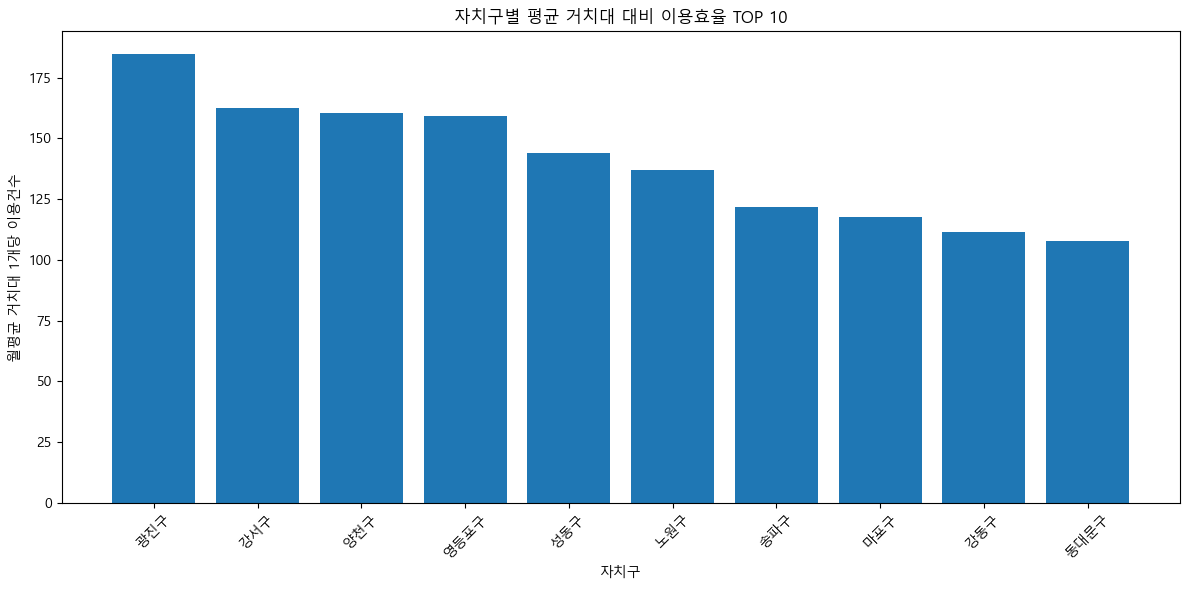

In [33]:
plot_df = district_summary_df.head(10).copy()
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(plot_df["district"], plot_df["avg_monthly_rides_per_rack"])
ax.set_title("자치구별 평균 거치대 대비 이용효율 TOP 10")
ax.set_xlabel("자치구")
ax.set_ylabel("월평균 거치대 1개당 이용건수")
ax.tick_params(axis="x", rotation=45)
save_fig("10_district_avg_monthly_rides_per_rack.png")
plt.show()

saved: d:\seoul-bike-aarrr-analysis\images\station_operation_efficiency\10_district_over_demand_station_count.png


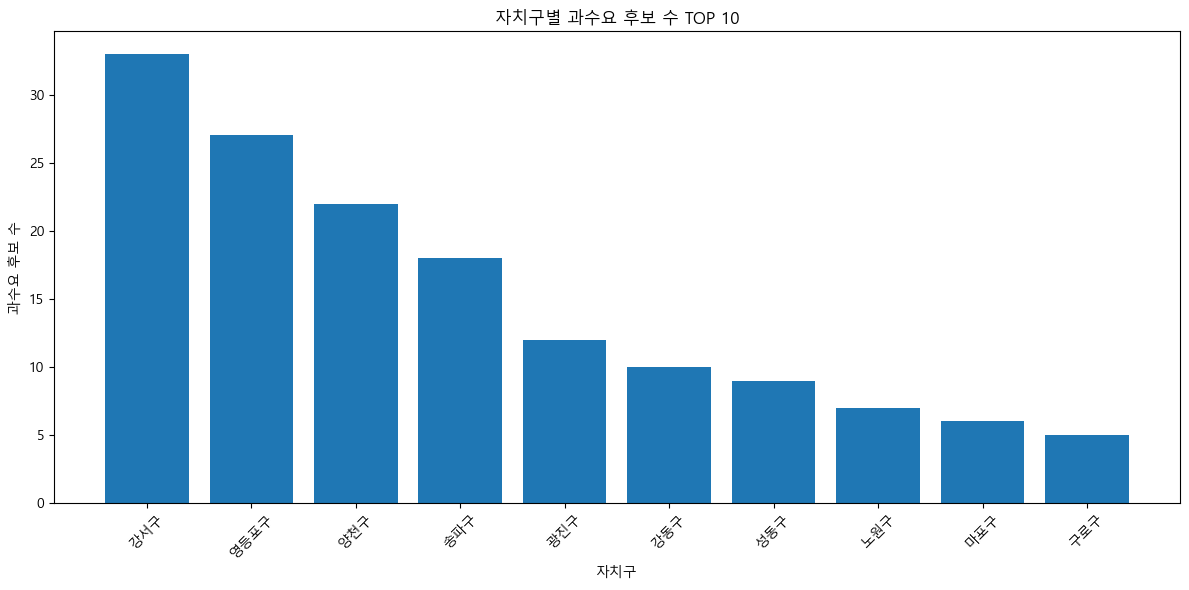

In [34]:
plot_df = district_summary_df.sort_values("over_demand_station_count", ascending=False).head(10).copy()
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(plot_df["district"], plot_df["over_demand_station_count"])
ax.set_title("자치구별 과수요 후보 수 TOP 10")
ax.set_xlabel("자치구")
ax.set_ylabel("과수요 후보 수")
ax.tick_params(axis="x", rotation=45)
save_fig("10_district_over_demand_station_count.png")
plt.show()

saved: d:\seoul-bike-aarrr-analysis\images\station_operation_efficiency\10_district_under_use_station_count.png


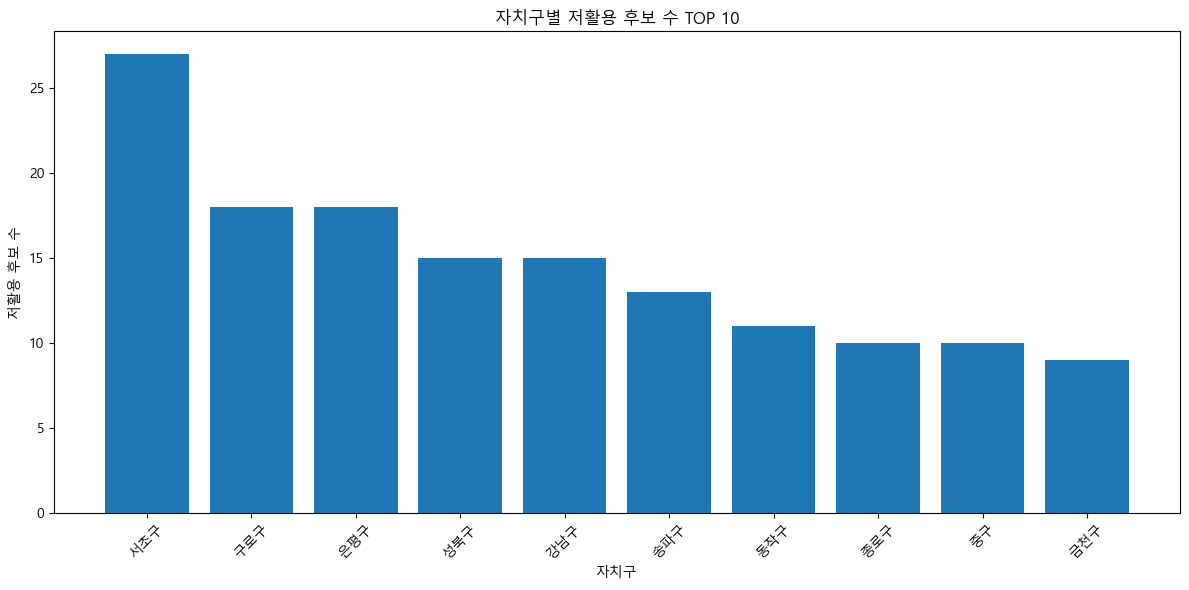

In [35]:
plot_df = district_summary_df.sort_values("under_use_station_count", ascending=False).head(10).copy()
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(plot_df["district"], plot_df["under_use_station_count"])
ax.set_title("자치구별 저활용 후보 수 TOP 10")
ax.set_xlabel("자치구")
ax.set_ylabel("저활용 후보 수")
ax.tick_params(axis="x", rotation=45)
save_fig("10_district_under_use_station_count.png")
plt.show()

In [36]:
district_summary_df["over_demand_station_share"] = (district_summary_df["over_demand_station_count"] / district_summary_df["station_count"])
district_summary_df["under_use_station_share"] = (district_summary_df["under_use_station_count"] / district_summary_df["station_count"])

#% 컬럼 추가
district_summary_df["over_demand_station_share_pct"] = (district_summary_df["over_demand_station_share"] * 100).round(2)
district_summary_df["under_use_station_share_pct"] = (district_summary_df["under_use_station_share"] * 100).round(2)

# 컬럼 순서 정리
district_summary_view = district_summary_df[
    [
        "district",
        "station_count",
        "total_ride_cnt",
        "avg_monthly_ride_cnt_per_station",
        "avg_rack_cnt",
        "avg_monthly_rides_per_rack",
        "over_demand_station_count",
        "over_demand_station_share_pct",
        "under_use_station_count",
        "under_use_station_share_pct",
    ]
].copy()

district_summary_view

,district,station_count,total_ride_cnt,avg_monthly_ride_cnt_per_station,avg_rack_cnt,avg_monthly_rides_per_rack,over_demand_station_count,over_demand_station_share_pct,under_use_station_count,under_use_station_share_pct
0,광진구,76,3616489,1982.72,12.61,184.82,12,15.79,2,2.63
1,강서구,181,9609738,2212.19,15.46,162.40,33,18.23,2,1.10
2,양천구,101,4756654,1962.32,12.93,160.33,22,21.78,3,2.97
3,영등포구,149,6879494,1923.80,12.99,159.39,27,18.12,4,2.68
4,성동구,88,2961143,1402.06,10.82,143.97,9,10.23,9,10.23
5,노원구,131,4508276,1433.93,11.40,137.00,7,5.34,4,3.05
6,송파구,206,7156306,1447.47,12.55,121.72,18,8.74,13,6.31
7,마포구,117,3753051,1336.56,12.35,117.57,6,5.13,5,4.27
8,강동구,105,3427570,1360.15,12.57,111.46,10,9.52,8,7.62
9,동대문구,76,2299699,1260.80,12.58,107.65,3,3.95,2,2.63


saved: d:\seoul-bike-aarrr-analysis\images\station_operation_efficiency\10_district_over_demand_share_top10.png


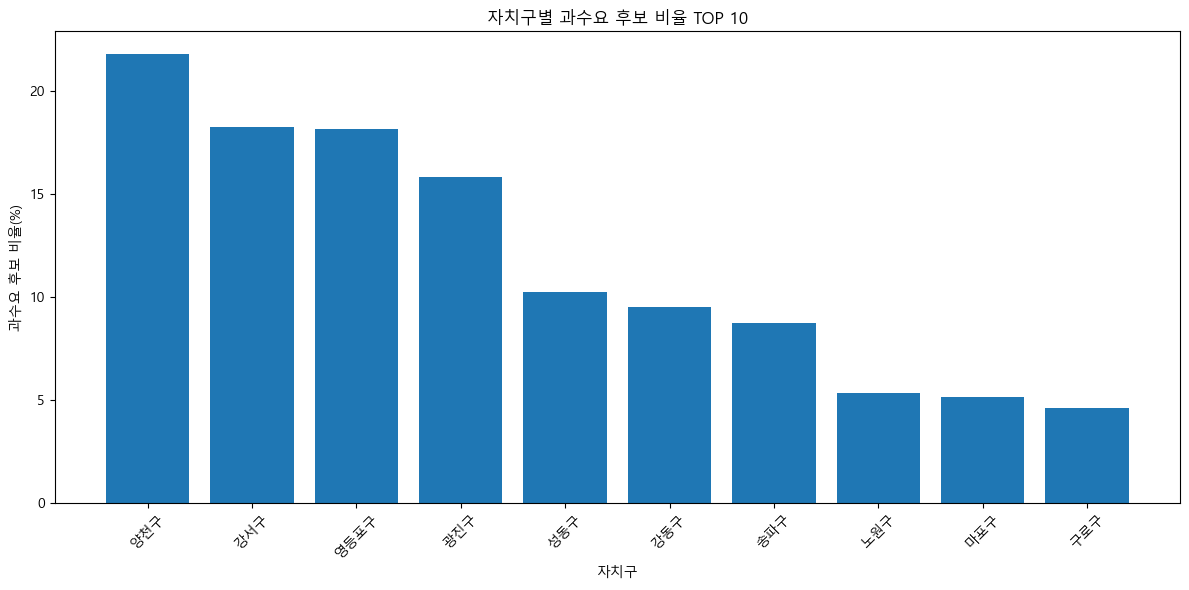

In [37]:
over_demand_share_top10 = district_summary_view.sort_values("over_demand_station_share_pct", ascending=False).head(10).copy()
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(over_demand_share_top10["district"], over_demand_share_top10["over_demand_station_share_pct"])
ax.set_title("자치구별 과수요 후보 비율 TOP 10")
ax.set_xlabel("자치구")
ax.set_ylabel("과수요 후보 비율(%)")
ax.tick_params(axis="x", rotation=45)
save_fig("10_district_over_demand_share_top10.png")
plt.show()

saved: d:\seoul-bike-aarrr-analysis\images\station_operation_efficiency\10_district_under_use_share_top10.png


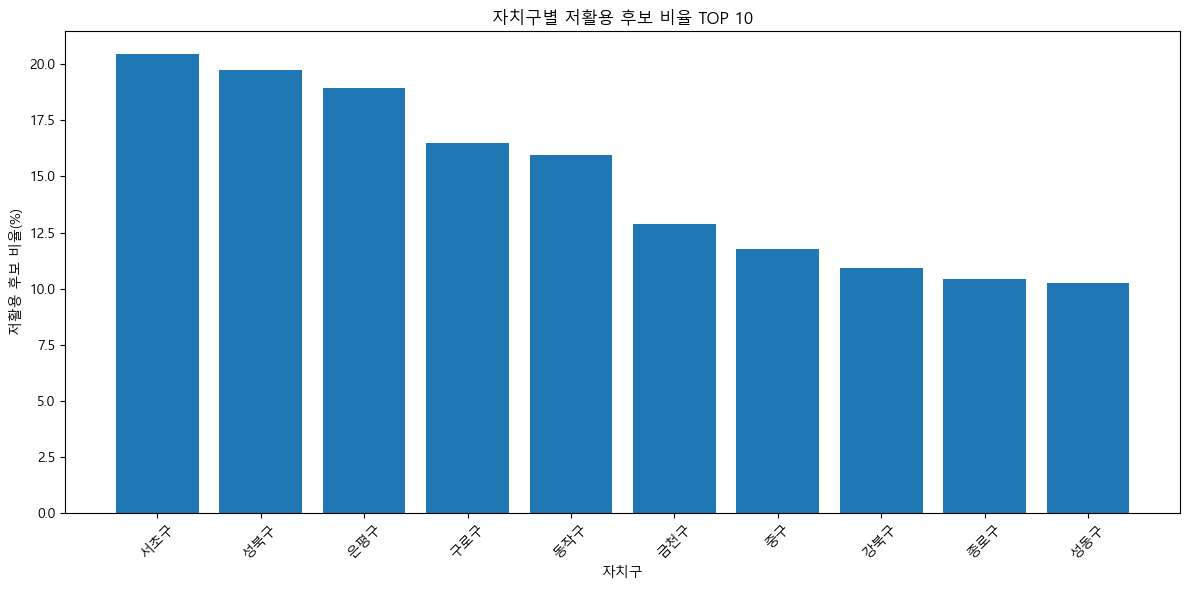

In [38]:
over_demand_share_top10 = district_summary_view.sort_values("under_use_station_share_pct", ascending=False).head(10).copy()
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(over_demand_share_top10["district"], over_demand_share_top10["under_use_station_share_pct"])
ax.set_title("자치구별 저활용 후보 비율 TOP 10")
ax.set_xlabel("자치구")
ax.set_ylabel("저활용 후보 비율(%)")
ax.tick_params(axis="x", rotation=45)
save_fig("10_district_under_use_share_top10.png")
plt.show()

In [39]:
sql_output_path = SQL_DIR / '09_station_operation_efficiency_mart_columns_queries.sql'

sql_sections = [('0) mart 검증', 'check_sql'), ('1) 대여소별 이용건수', 'station_usage_sql'), ('2) 거치대 대비 이용효율', 'station_efficiency_sql'), ('3) 과수요/저활용 대여소 식별', 'station_type_sql'), ('4) 월별 반복 과수요 후보', 'monthly_over_sql'), ('5) 월별 반복 저활용 후보', 'monthly_under_sql'), ('6) 10분위 기준 과수요/저활용 대여소 식별', 'station_type_10tile_sql'), ('7) 10분위 기준 월별 반복 과수요 후보', 'monthly_over_10tile_sql'), ('8) 10분위 기준 월별 반복 저활용 후보', 'monthly_under_10tile_sql'), ('9) 자치구별 운영 효율 요약', 'district_summary_sql')]

sql_header = '''-- 09. 운영 효율 분석 SQL'''

def normalize_sql(sql: str) -> str:
    sql = sql.strip()
    return sql if sql.endswith(';') else sql + ';'

sql_parts = [sql_header]
for section_title, sql_var_name in sql_sections:
    sql_parts.append(
        "\n".join([
            "-" * 80,
            f"-- {section_title}",
            "-" * 80,
            normalize_sql(globals()[sql_var_name]),
        ])
    )

operation_efficiency_sql = "\n\n".join(sql_parts) + "\n"
sql_output_path.write_text(operation_efficiency_sql, encoding='utf-8')
print('saved:', sql_output_path)
conn.close()
print('DB connection closed')


saved: d:\seoul-bike-aarrr-analysis\sql\09_station_operation_efficiency_mart_columns_queries.sql
DB connection closed
